# Liquidez multi-banco — diagnóstico, corrección y política de rebalanceo

Rehacer el notebook del squad para responder la pregunta real: **¿cuándo, cuánto y desde dónde mover dinero
entre 6 cuentas en 3 monedas para minimizar el riesgo de faltante sin mover dinero de más?**

**Cómo leer este notebook.** Toda la lógica vive en [`src/`](../src/) (ingesta, calidad, forecast, políticas, MILP,
backtest) y tiene pruebas (`pytest`, 28 tests). Aquí solo se importa y se muestra. Cada celda de cifras se genera
desde los datos: si cambias un supuesto en [`src/config.py`](../src/config.py) y reejecutas, las tablas y los textos numéricos se actualizan.

| Parte | Qué responde |
|---|---|
| **0** | Supuestos declarados (todo lo que *no* está en los datos) |
| **1** | Qué está mal en el enfoque del squad, con evidencia (D1–D10), y el pipeline corregido |
| **2** | Enfoque propuesto: forecast probabilístico → política de cuantil → MILP → backtest con frontera costo–riesgo |
| **3** | Dos explicaciones: para el data scientist y para Tesorería |
| **4 / 5** | Formas de trabajo (uso de IA) y productivización |

> **Tiempo de ejecución:** ~5–6 min (el backtest resuelve un MILP por día y por política).

## Índice

  - 0 · Supuestos declarados
- Parte 1 · Diagnóstico y corrección del enfoque del squad
  - 1.1 Punto de partida: el notebook del squad, reproducido
  - 1.2 Los datos: qué está roto y cómo se corrige
    - D1 · `dropna` silencioso tras `coerce`: el squad pierde el 17,6% de la historia
    - El pipeline corregido (`src/ingest.py`) y su reporte de calidad
    - D2 · Duplicados y errores de signo/escala nunca detectados → el forecast del squad se contamina durante 14 días
    - D3 · 9 etiquetas de moneda tratadas como distintas
    - D4 · El forecast es la media móvil 14d del **nivel**: sin drift, sin estacionalidad, sin horizonte
    - D5 · Sin incertidumbre
    - D6 · Donante = `idxmax()` del balance **nominal**, sin convertir moneda
    - D4b–D4d · Estacionalidad, validación de nivel y XGBoost (resumen; detalle en Anexo técnico A)
    - D7 · Umbrales fijos inventados, solo para 4 de 6 cuentas
    - D8 y D9 · `transfer_today: True` ignora el lag; los fees se ignoran
    - D10 · Validación circular: promedio de saldos antes/después del 1-mayo, sumando COP+USD+MXN
- Parte 2 · Un enfoque sólido a la pregunta real
  - 2.0 Formulación (qué significa "faltante" y cómo se decide)
  - 2.1 Reconciliación: ¿el log de transferencias explica algo de los saldos?
  - 2.2 Estructura de los flujos
  - 2.3 Forecast probabilístico: escalera de modelos con backtest walk-forward
  - 2.4 El piso operativo: qué K es defendible
  - 2.5 Capa 1 — Política de cuantil (la que se explica a Tesorería)
  - 2.6 Capa 2 — Optimización (la que se explica al data scientist)
  - 2.7 Backtest: tres políticas, mismos datos, mismo forecast, contrafactual explícito
    - El caso en que el MILP decide **no** transferir aunque hay faltante proyectado
  - 2.8 Sensibilidad
    - 2.7b · La versión sencilla: cuantil + espera (política D)
  - 2.9 Dónde puede seguir fallando
- Parte 3 · Dos explicaciones de lo mismo
  - 3.1 Para el data scientist del squad
  - 3.2 Para Tesorería
- Parte 4 · Formas de trabajo: dónde se usó IA y dónde no
- Parte 5 · De notebook a producción (media página)
- Anexo técnico A · Estacionalidad, validación de nivel con `TimeSeriesSplit` y XGBoost
- Decisiones abiertas y verificación
  - Decisiones humanas pendientes (por orden de impacto)

## Resumen ejecutivo

*(cifras del run de este notebook; la última celda verifica que se cumplan)*

- **El "parece funcionar" del squad es falso.** Su pipeline pierde el 17,6% de las filas, trata 9 etiquetas como 9 monedas, deja pasar 7 lecturas corruptas y 6 episodios inexplicables, elige el donante por saldo *nominal* sin convertir moneda, y "valida" con un promedio antes/después que suma COP+USD+MXN (−9,6% presentado como éxito).
- **Datos corregidos con la identidad contable** (`b[t]=b[t-1]+in−out`): panel 6 × 270, 0 nulos, 0 negativos, residuo ≈ 0,01. Lo inexplicable va a cuarentena marcada, no se adivina.
- **Forecast del flujo neto, con distribución.** Todos los modelos ganan ~26–34% al naive estacional, pero **ninguno gana a un bootstrap empírico** (la media del flujo neto casi no tiene señal): el valor está en los cuantiles, con cobertura p5–p95 de ~93%.
- **Backtest con contrafactual** (210 días × 6 cuentas, piso = 25 días de egresos): sin intervenir hay **33 días-cuenta en faltante**; la regla del squad, **86** (peor que nada, USD 6,3 mil, 200 transferencias); la política de cuantil, **0** (USD 5,0 mil, 49 transferencias); el **MILP, 0** (USD 2,1 mil, 22 transferencias, todas de la misma moneda — de hecho, dentro de 3 pools operativa-reserva fijos, ver 2.7). El MILP también *decide no mover dinero* cuando operar cuesta más que la penalización esperada.
- **Sensibilidad:** robusto a FX ±10% y a lag forzado; **frágil a un forecast sesgado** (aparecen 1–3 días en faltante); con un piso de 30 días el sistema no tiene liquidez suficiente y el problema es de fondeo, no de rebalanceo.
- **Pendiente de decisión humana:** piso (K), FX oficial del COP, costo fijo, penalización, los 6 episodios sin explicar y qué representa el log de transferencias (que **no aparece en los saldos**). Ver el final del notebook.
- **Estacionalidad y validación temporal (D4b–D4d, Anexo A).** El patrón semanal está en las entradas y salidas, no en el saldo (paseo aleatorio con deriva: `d = 1`); XGBoost con rezagos no supera de forma clara al "último saldo" (gana en 18 de 30 bloques). Redundante con 2.3, por eso queda en el anexo.
- **Regla sencilla de espera (2.7b).** Esperar cuando el faltante solo está en la cola y aún hay holgura baja las transferencias de 49 a 13 y el costo de USD 4.955 a USD 2.555, pero deja 3 días-cuenta en faltante; el MILP logra 0 faltantes con USD 2.099. La regla sirve para identificar oportunidades y explicar la decisión, no para reemplazar al MILP.

In [1]:
import sys
from pathlib import Path

# el notebook vive en notebooks/: se sube hasta encontrar la carpeta src/
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import config as cfg, ingest, quality, features, diagnosis as D
from src import forecast as F, policy as P, optimize as O, backtest as B, plots

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", "{:,.2f}".format)

## 0 · Supuestos declarados

Todo lo que **no es observable en los datos** está aquí y en [`src/config.py`](../src/config.py); ninguna constante de negocio vive en el código.
Los marcados **[DECISIÓN HUMANA]** son valores por defecto razonables, **pendientes de validación por Tesorería**; el backtest los
somete a sensibilidad (Parte 2.8) precisamente para no depender de ellos a ciegas.

In [2]:
cfg.assumptions_table()

,supuesto,valor,origen / nota
0,FX (unid. por USD),"{'USD': 1.0, 'MXN': 18.4457, 'COP': 3900.0}","[DECISIÓN HUMANA] MXN: FIX Banxico 26-sep-2025 = 18,4457. COP: aproximado ~3.900, pendiente de sustituir por la TRM oficial (Banco de la..."
1,Fee variable,"{'same_ccy': 0.0004, 'cross_ccy': 0.0027}","Observado en el log: misma moneda 0,04% fijo; cross 0,15-0,40%"
2,Lag observado,"{'same_ccy': {0: 20, 1: 5}, 'cross_ccy': {1: 37, 2: 57, 3: 26}}",Observado en el log
3,Lag de planificación,"{'same_ccy': 1, 'cross_ccy': 3}",p90 por tipo (conservador)
4,Costo fijo por operación (USD),25.0,[DECISIÓN HUMANA] no observable
5,Penalización por déficit,0.20% del déficit por cuenta-día,[DECISIÓN HUMANA] define el punto en la frontera
6,Ponderación penalización,"{'operational': 1.0, 'reserve': 0.5}",operativa > reserva como destino
7,Piso operativo,"{'operational': 25.0, 'reserve': 25.0} días de egresos medios (28d)",[DECISIÓN HUMANA] define qué es 'faltante'
8,Monto mínimo de transferencia,1.0 día(s) de egresos del destino,evita goteo de micro-operaciones
9,Horizonte de decisión,"14 días, reoptimización diaria",spec §7


---
# Parte 1 · Diagnóstico y corrección del enfoque del squad

## 1.1 Punto de partida: el notebook del squad, reproducido

Se reejecuta **su código, sin tocarlo**, sobre el crudo. Es la evidencia sobre la que se diagnostica.

In [3]:
accounts = ingest.load_accounts()
raw_squad = ingest.load_raw_balances()          # el crudo, con la fecha como texto
transfers_raw = ingest.load_raw_transfers()

squad = D.squad_pipeline(accounts, raw_squad)   # coerce + dropna, media de 14 filas, umbral fijo, idxmax
print("filas que sobreviven en el pipeline del squad:", squad["balances"].shape[0], "de", len(raw_squad))
print("etiquetas de moneda 'distintas':", sorted(squad["balances"]["currency"].unique()))
print("\nforecast del squad (un escalar constante para los 7 días):")
print({k: f"{v:,.0f}" for k, v in squad["forecasts"].items()})
print("\nrecomendaciones del squad:")
pd.DataFrame(squad["recommendations"])

filas que sobreviven en el pipeline del squad: 1375 de 1668
etiquetas de moneda 'distintas': ['COP', 'Colombian Peso', 'MXN', 'Mexican Peso', 'US Dollar', 'USD', 'cop', 'mxn', 'usd']

forecast del squad (un escalar constante para los 7 días):
{'ACC-001': '2,305,518,572', 'ACC-002': '79,790', 'ACC-003': '2,920,535,273', 'ACC-004': '15,965,982', 'ACC-005': '107,312,810', 'ACC-006': '151,186'}

recomendaciones del squad:


,to_account,from_account,amount_needed,transfer_today
0,ACC-002,ACC-003,"20,210.32",True
1,ACC-004,ACC-003,"24,034,018.22",True


## 1.2 Los datos: qué está roto y cómo se corrige

El hallazgo que ordena todo: **los datos traen su propia llave de respuesta, la identidad contable**

> `balance[t] = balance[t-1] + inflow[t] − outflow[t]`

Cuadra al centavo en toda fila sana. Eso permite *elegir* el duplicado correcto (no promediar), *reconstruir* nulos de forma exacta,
*reparar* solo lo que tiene firma exacta (−1× o 10×) y *poner en cuarentena* —marcado y reportado— lo que no se puede explicar.

### D1 · `dropna` silencioso tras `coerce`: el squad pierde el 17,6% de la historia

In [4]:
loss = D.parse_loss_by_format(raw_squad)
display(loss)
lost = int(loss["perdidas"].sum())
print(f"El comentario del squad decía 'a few dates don't parse'. Son {lost} de {len(raw_squad)} filas = {lost/len(raw_squad):.1%}: "
      "TODA fecha que no sea ISO desaparece, y nadie fue avisado.")

,filas,sobreviven,perdidas
formato,,,
%Y-%m-%d,1375,1375,0
%d/%m/%Y,170,0,170
%m-%d-%Y,123,0,123


El comentario del squad decía 'a few dates don't parse'. Son 293 de 1668 filas = 17.6%: TODA fecha que no sea ISO desaparece, y nadie fue avisado.


### El pipeline corregido (`src/ingest.py`) y su reporte de calidad

In [5]:
data = ingest.run_pipeline()            # F1 completo; escribe data/processed/
panel, ledger, transfers = data["panel"], data["ledger"], data["transfers"]
quality.quality_report(data["raw"], ledger, panel, transfers_raw, data["transfers_excluded"])

,problema,afectados,tratamiento
0,Filas entrantes (crudo),"1,668.00",—
1,P1 fechas que el parser del squad pierde,293.00,cascada de 3 formatos: 0 no parseadas
2,P2 etiquetas de moneda (deben ser 3),9.00,normalizadas a ISO-4217 y validadas vs accounts.csv
3,P2 filas con etiqueta no canónica,187.00,→ moneda de la cuenta
4,"P3 pares (fecha, cuenta) duplicados con balance distinto",44.00,se conserva la fila que cuadra con la identidad
5,P3 pares duplicados exactos/ambos nulos,4.00,se colapsan; balance por identidad
6,P4 nulos en balance,68.00,reconstruidos por identidad
7,P4 nulos en inflow,65.00,recuperados por identidad o imputados (marca)
8,P4 nulos en outflow,65.00,recuperados por identidad o imputados (marca)
9,P5 balances negativos en el crudo,4.00,todos sign-flip exacto (-1x) → reparados


**Criterios de aceptación de F1**, verificados por `ingest.validate_panel` (falla si algo no cumple) y por `tests/test_ingest.py`:
1.668 filas leídas → 0 fechas sin parsear · 6 cuentas × 270 días = 1.620 filas sin huecos de calendario · 0 balances negativos · 0 nulos ·
la identidad contable cuadra en el 100% de los días (residuo máx. ≈ 0,01 unidades).

Tres cosas que este análisis **corrige respecto del spec**, porque los datos las contradicen:

1. **No son 4 errores puntuales sino 7** (4 signos invertidos y 3 decimales corridos ×10), **más 6 episodios de 3 días** (65–85% de caída y rebote) que
   *ninguna* regla explica: los flujos registrados no los justifican ni tampoco el log de transferencias. No se adivinan: se
   **ponen en cuarentena** (puente lineal entre el último y el primer saldo confiables, `reliable = False`) y se preguntan a la fuente.
2. **Los 4 negativos son datos, no faltantes**: tras repararlos, ninguna cuenta queda negativa jamás. El "ACC-004 sale negativo" del squad no es ruido ni sobregiro real.
3. **Hay 5 transferencias duplicadas** en el log (todo igual salvo `transfer_id`), que se excluyen y reportan.

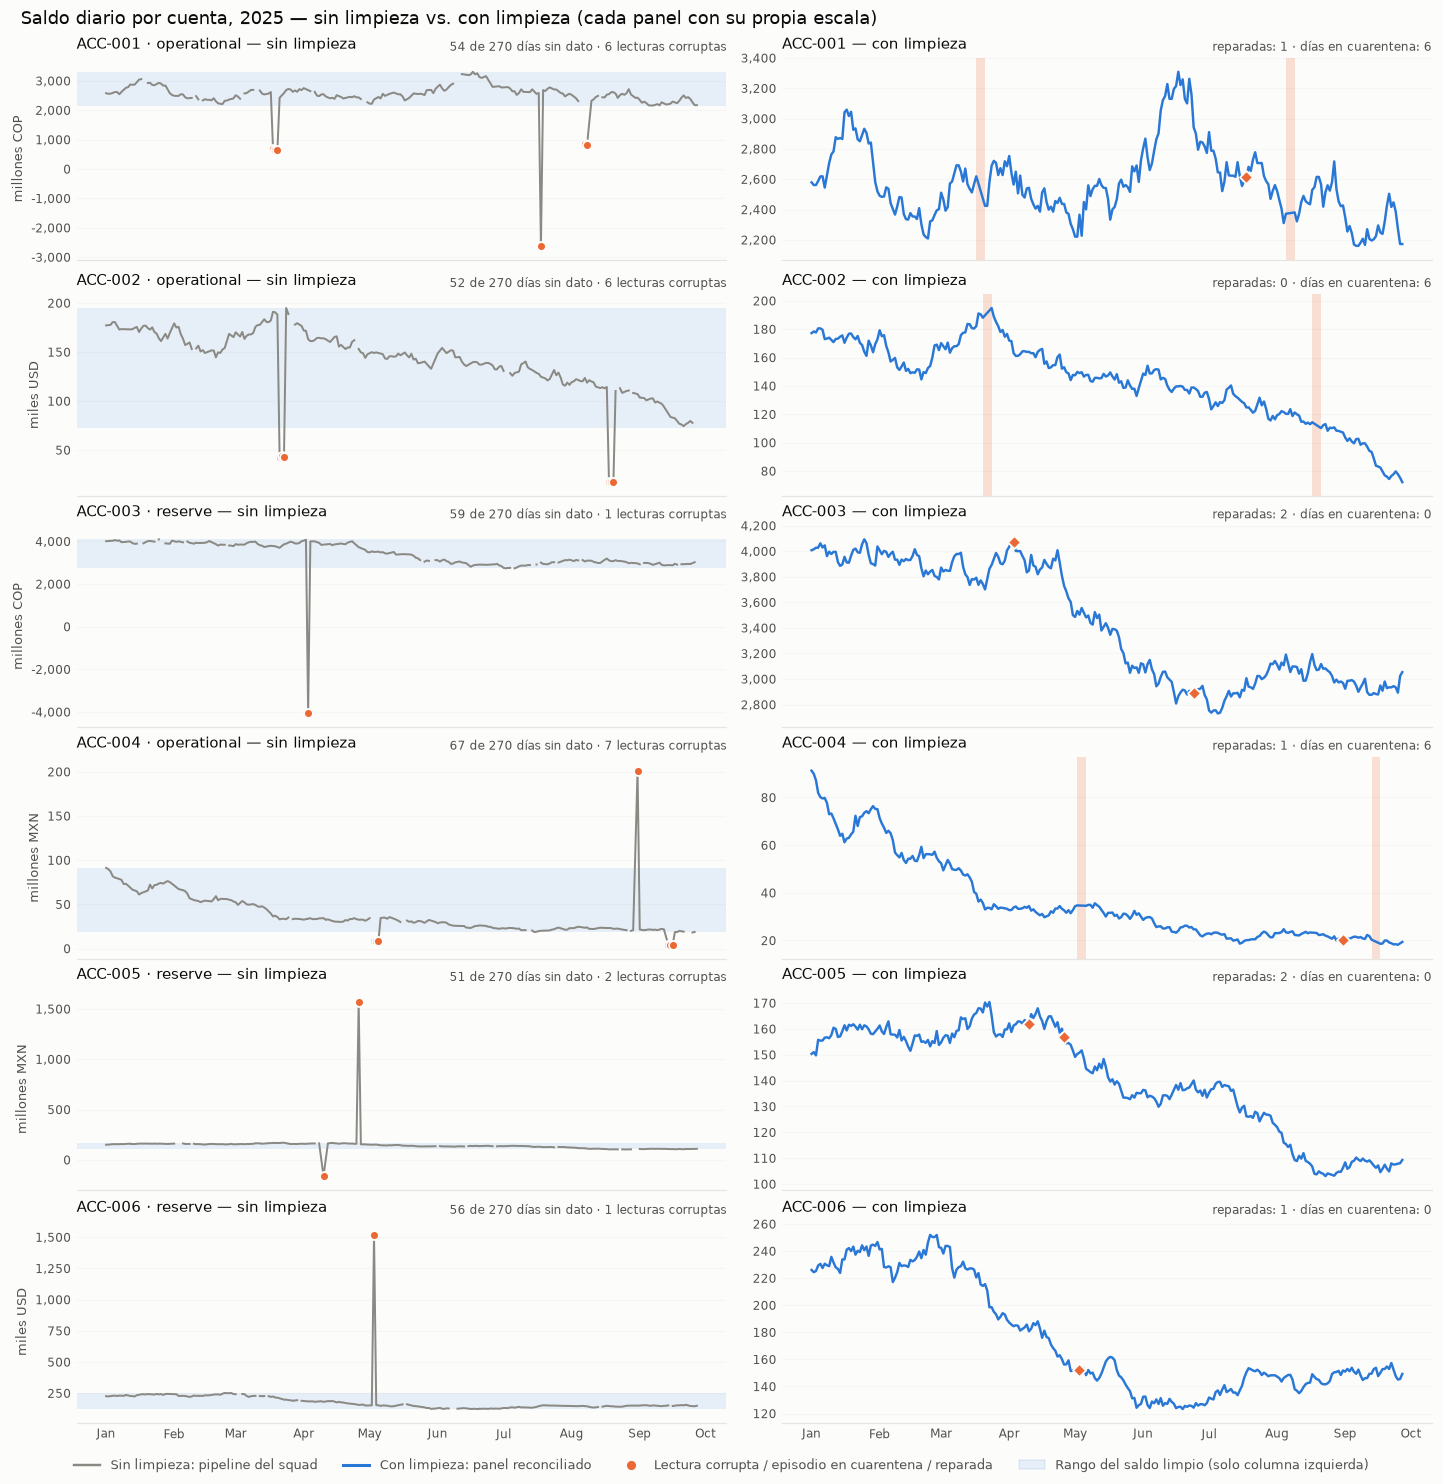

In [6]:
fig = plots.fig_cleaning(data["raw"], panel)
plt.show()

### D2 · Duplicados y errores de signo/escala nunca detectados → el forecast del squad se contamina durante 14 días

Un solo dato malo permanece 14 días dentro de una media móvil de 14. Se compara **el mismo forecast del squad** sobre sus datos
vs. sobre los datos corregidos (aísla el efecto de los *datos* del efecto del *método*):

In [7]:
flows = F.net_flow_matrix(panel)
book = P.Book.from_panel(panel)
store = B.ForecastStore(flows, "empirical")          # forecast por origen, sin lookahead, compartido por todas las políticas

contam = D.contamination_table(squad["balances"], panel)
display(contam)
print(f"Días en que el forecast del squad se aleja >10% del forecast sobre datos limpios: {int(contam['dias_con_desvio>10%'].sum())} "
      f"(desvío máximo {contam['desvio_max_%'].max():.0f}%).")

,dias_comparados,dias_con_desvio>10%,desvio_max_%,alertas_con_datos_squad,alertas_con_datos_limpios
account_id,,,,,
ACC-001,101,20,15.04,0.00,0.00
ACC-002,140,7,17.19,11.00,10.00
ACC-003,92,14,14.79,NaN,NaN
ACC-004,126,8,55.64,72.00,73.00
ACC-005,112,16,68.44,NaN,NaN
ACC-006,118,11,65.60,0.00,0.00


Días en que el forecast del squad se aleja >10% del forecast sobre datos limpios: 76 (desvío máximo 68%).


Eso es el "**el forecast de ACC-004 a veces sale disparatado día a día**" del squad: no es ruido a suavizar —como iban a hacer— sino
datos corruptos entrando a una ventana. Añadir suavizado habría empeorado el problema.

### D3 · 9 etiquetas de moneda tratadas como distintas
Se ve en su propio `unique()` de la celda 3 (arriba: 9 etiquetas para 3 monedas). Cada cuenta usa solo variantes de *su* moneda
(0 filas en moneda equivocada), así que es un problema de etiquetas: `accounts.csv` es la fuente de verdad y se normaliza a ISO-4217 con validación cruzada.

### D4 · El forecast es la media móvil 14d del **nivel**: sin drift, sin estacionalidad, sin horizonte
Los saldos de las 6 cuentas **derivan a la baja** (flujo neto medio negativo); una media de niveles pasados los sobreestima siempre.
Backtest (origen diario, saldo a 7 y 14 días, datos limpios) del pronóstico del squad frente a la referencia más ingenua posible: *"el saldo de mañana = el de hoy"*.

mae_squad     mae_ultimo  mae_propuesto  ultimo/squad  propuesto/squad  sesgo del squad (+ = sobreestima)
h  account_id                                                                                                               
7  ACC-001    179,408,073.19 137,165,073.24 143,615,386.78          0.76             0.80                       7,746,898.17
   ACC-002          9,500.29       6,796.28       6,478.85          0.72             0.68                           5,493.17
   ACC-003    129,723,808.16  97,802,766.88  99,773,467.94          0.75             0.77                      60,659,253.84
   ACC-004      2,974,378.23   2,021,411.63   2,435,063.88          0.68             0.82                       2,256,230.81
   ACC-005      5,886,343.94   4,215,279.77   4,216,991.12          0.72             0.72                       3,226,604.10
   ACC-006         10,780.42       7,373.04       7,593.39          0.68             0.70                           5,981.74
14 ACC-001    211,568,637.59 200,816,478.21 213,798,150.73          0.95             1.01                      22,611,433.21
   ACC-002         12,362.45       9,900.57       8,812.94          0.80             0.71                           8,599.95
   ACC-003    175,570,989.21 146,488,568.83 139,088,867.13          0.83             0.79                      96,740,113.86
   ACC-004      4,108,598.97   3,106,893.16   4,148,441.02          0.76             1.01                       3,318,478.52
   ACC-005      7,791,329.40   6,507,568.86   6,444,649.24          0.84             0.83                       5,242,640.74
   ACC-006         15,271.81      11,517.85      12,024.79          0.75             0.79                           8,974.21

'Último saldo' le gana al forecast del squad en 100% de las combinaciones cuenta × horizonte (error 23% menor en promedio), y el squad sobreestima siempre (sesgo > 0 en todas).


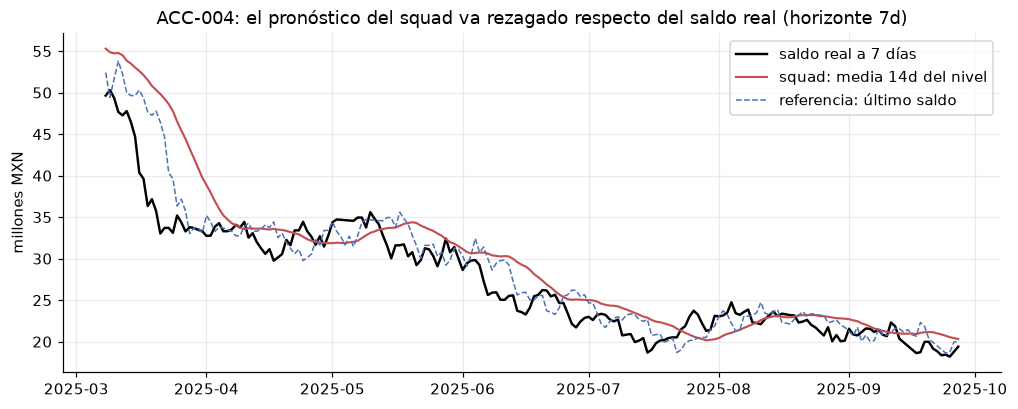

In [8]:
lvl, lvl_series = D.level_forecast_backtest(panel, store)
show = lvl[["account_id", "h", "mae_squad", "mae_ultimo", "mae_propuesto", "mae_ultimo_rel", "mae_propuesto_rel", "sesgo_squad"]].copy()
show = show.rename(columns={"mae_ultimo_rel": "ultimo/squad", "mae_propuesto_rel": "propuesto/squad", "sesgo_squad": "sesgo del squad (+ = sobreestima)"})
display(show.set_index(["h", "account_id"]))
better = (lvl["mae_ultimo"] < lvl["mae_squad"]).mean()
print(f"'Último saldo' le gana al forecast del squad en {better:.0%} de las combinaciones cuenta × horizonte "
      f"(error {(1 - lvl['mae_ultimo_rel']).mean():.0%} menor en promedio), y el squad sobreestima siempre (sesgo > 0 en todas).")
fig = plots.fig_squad_forecast(lvl_series, "ACC-004", 7); plt.show()

Lectura honesta: **a nivel puntual el mejor pronosticador del saldo es "el último saldo"** (paseo aleatorio con deriva), no algo sofisticado —lo verifica la
Parte 2. Nuestro aporte no es más precisión puntual sino **la distribución** (D5). El squad, encima, pronostica *peor que no pronosticar*.

### D5 · Sin incertidumbre
Un escalar no puede dimensionar un buffer: decidir cuánto colchón se necesita exige saber *qué tan mal* puede ir. La Parte 2 entrega cuantiles
p5–p95 calibrados (cobertura empírica reportada).

### D6 · Donante = `idxmax()` del balance **nominal**, sin convertir moneda
Una cuenta COP siempre gana por magnitud. Los mismos saldos, en USD equivalente (FX de config):

### D4b–D4d · Estacionalidad, validación de nivel y XGBoost (resumen; detalle en Anexo técnico A)

La estacionalidad semanal vive en los flujos **brutos** (entradas y salidas caen ~50% el fin de semana), no en el **neto**: al
diferenciarlos la serie queda estacionaria (ADF/KPSS) y sin estructura semanal explotable en el ACF/PACF — coherente con el
resultado de 2.3 (ningún modelo le gana a `empirical` en el neto). Validando el **nivel** con `TimeSeriesSplit` (ventana expansiva,
mismos cortes para ETS y XGBoost con rezagos), XGBoost tiene el menor error puntual pero solo gana al "último saldo" en 18 de 30
bloques cuenta×corte: no hay ventaja clara y consistente. Esta validación queda fuera del flujo principal por ser redundante con
2.3 (mismo hallazgo, otro horizonte y otra métrica); el detalle completo —incluido el squad sobreestimando +4,2% en promedio
(+17% en ACC-004) sobre datos sin limpiar— está en el **Anexo técnico A**, al final del notebook.

In [9]:
donors = D.donor_table(panel)
display(donors)
print("El squad elige como donante:", squad["recommendations"][0]["from_account"], "(COP, ranking nominal #1) -> en USD equivalente es la #3;",
      "la #1 real es ACC-005 (MXN reserve).")

,currency,account_type,balance,balance_usd_eq,rank_nominal (squad),rank_usd_eq
account_id,,,,,,
ACC-001,COP,operational,"2,172,487,717.48","557,048.13",2,4
ACC-002,USD,operational,"72,155.97","72,155.97",6,6
ACC-003,COP,reserve,"3,054,007,545.39","783,078.86",1,3
ACC-004,MXN,operational,"19,392,053.57","1,051,304.83",4,2
ACC-005,MXN,reserve,"109,313,393.57","5,926,226.36",3,1
ACC-006,USD,reserve,"149,275.09","149,275.09",5,5


El squad elige como donante: ACC-003 (COP, ranking nominal #1) -> en USD equivalente es la #3; la #1 real es ACC-005 (MXN reserve).


Peor aún: el monto se calcula en unidades de la moneda **destino** y se gira en la del **donante**. Los USD 20.210 que necesita ACC-002 salen como
20.210 *pesos colombianos* (≈ USD 5). El banco convierte al FX real y llega una fracción de lo necesario; el backtest (2.7) mide ese efecto.

### D7 · Umbrales fijos inventados, solo para 4 de 6 cuentas

In [10]:
D.threshold_table(panel)

,tipo,moneda,umbral_squad,saldo_mediano,umbral / mediana,% de dias con saldo < umbral
account_id,,,,,,
ACC-001,operational,COP,"1,000,000,000.00","2,546,728,453.72",0.39,0.00
ACC-002,operational,USD,"100,000.00","147,451.04",0.68,7.78
ACC-003,reserve,COP,NaN,"3,397,081,173.15",NaN,NaN
ACC-004,operational,MXN,"40,000,000.00","31,193,123.84",1.28,72.22
ACC-005,reserve,MXN,NaN,"142,094,094.25",NaN,NaN
ACC-006,reserve,USD,"100,000.00","152,799.29",0.65,0.00


Las dos cuentas **reserva** (ACC-003, ACC-005) no tienen umbral: nunca se protegen pero sí se vacían como donantes. El umbral de ACC-004
(40M MXN) está **por encima de su propia mediana** (×1,28): la regla dispara ~72% de los días *por construcción*, no por riesgo.
Los de ACC-001 y ACC-006 no se activan nunca. Es calibración por intuición.

### D8 y D9 · `transfer_today: True` ignora el lag; los fees se ignoran
El log real tiene **dos regímenes** que el spec agrega en un solo número (lag mediana 2, fee media 0,23%) y que cambian la decisión:

,n,lag_min,lag_mediana,lag_max,fee_min_pct,fee_media_pct,fee_max_pct
kind,,,,,,,
cross_ccy,115,1,2.00,3,0.15,0.27,0.40
same_ccy,25,0,0.00,1,0.04,0.04,0.04


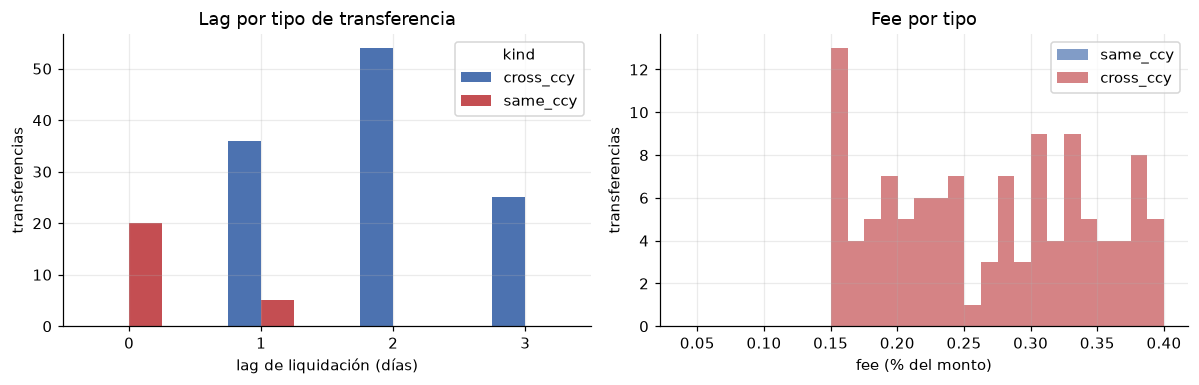

In [11]:
prof = transfers.groupby("kind").agg(
    n=("amount", "size"), lag_min=("lag_days", "min"), lag_mediana=("lag_days", "median"), lag_max=("lag_days", "max"),
    fee_min_pct=("fee_rate", lambda s: s.min() * 100), fee_media_pct=("fee_rate", lambda s: s.mean() * 100), fee_max_pct=("fee_rate", lambda s: s.max() * 100),
)
display(prof)
fig = plots.fig_lag_fee(transfers); plt.show()

- **Misma moneda:** fee **exactamente 0,04%** y lag 0–1 días. **Cross-moneda:** fee 0,15–0,40% (media ≈ 0,27%) y lag 1–3 días.
  Mover dinero dentro de la misma moneda es ~7× más barato y más rápido: cada cuenta operativa tiene una reserva de su misma moneda.
- Una transferencia ordenada hoy **no** cubre un faltante de hoy; el squad no modela el lag y por eso su regla se dispara todos los días sobre el mismo faltante (no ve lo que ya está en tránsito).
- La *tasa* del fee no decrece con el monto (correlación ≥ 0 dentro de cada moneda; un componente fijo la haría bajar) ⇒ **el costo fijo por operación no es observable en los datos**; es un supuesto declarado.

### D10 · Validación circular: promedio de saldos antes/después del 1-mayo, sumando COP+USD+MXN
Es el defecto más grave: no hay contrafactual, la métrica es la equivocada y suma monedas.

In [12]:
pp = D.pre_post(squad["balances"], panel, accounts)
display(pp)
w = D.currency_weight_in_squad_mean(squad["balances"], accounts)
print("Peso de cada moneda en el 'promedio de saldos' del squad:", {k: f"{v:.1%}" for k, v in w.items()})
print(f"\nSu propia celda imprime 'Looks like it's working, balances are up {pp.loc[0, 'cambio_%']:.1f}%': un −9,6% presentado como éxito.")

,vista,antes,despues,cambio_%
0,"squad: COP+USD+MXN sumados, datos crudos","1,068,097,438.63","965,805,394.31",-9.58
1,"COP solo, datos limpios","3,236,662,799.48","2,816,070,130.04",-12.99
2,"USD solo, datos limpios","191,614.35","133,182.93",-30.49
3,"MXN solo, datos limpios","105,498,451.19","74,878,102.93",-29.02


Peso de cada moneda en el 'promedio de saldos' del squad: {'COP': '97.0%', 'MXN': '3.0%', 'USD': '0.0%'}

Su propia celda imprime 'Looks like it's working, balances are up -9.6%': un −9,6% presentado como éxito.


1. **Suma monedas:** el "promedio" es ~97% pesos colombianos por pura magnitud nominal; USD y MXN no cuentan.
2. **Métrica equivocada:** un saldo más alto no es éxito (es costo de oportunidad) y uno más bajo no es fracaso; lo que importa es faltantes evitados vs. costo.
3. **Sin contrafactual:** antes/después confunde la política con la tendencia (los saldos derivan a la baja en *todas* las cuentas, −13% a −30% por moneda) y con la estacionalidad. Además, los datos muestran que el log de transferencias **ni siquiera está reflejado en los saldos** (Parte 2.1): no hay evidencia de que se haya rebalanceado el 1-mayo.

La forma correcta de evaluar es un **backtest walk-forward contra un contrafactual, con métricas de riesgo y de costo por moneda** (2.7).

In [13]:
d = pd.DataFrame([
    ("D1", "dropna tras coerce", f"{lost}/{len(raw_squad)} filas perdidas ({lost/len(raw_squad):.1%})"),
    ("D2", "duplicados / sign flips / ×10 sin detectar", f"forecast >10% distinto en {int(contam['dias_con_desvio>10%'].sum())} días-cuenta; hasta {contam['desvio_max_%'].max():.0f}%"),
    ("D3", "9 etiquetas de moneda", f"{squad['balances']['currency'].nunique()} etiquetas para 3 monedas"),
    ("D4", "media 14d del nivel", f"'último saldo' tiene {(1 - lvl['mae_ultimo_rel']).mean():.0%} menos error; el squad sobreestima en {(lvl['sesgo_squad'] > 0).mean():.0%} de los casos"),
    ("D5", "sin incertidumbre", "0 cuantiles; escalar constante a 7 días"),
    ("D6", "donante = idxmax nominal", f"elige {squad['recommendations'][0]['from_account']} (COP) — la #3 en USD eq; monto girado en la moneda equivocada"),
    ("D7", "umbrales fijos, 4 de 6", "reservas sin umbral; ACC-004: umbral/mediana = 1,28 → dispara ~72% de los días"),
    ("D8", "ignora el lag (0–3 d)", "misma moneda 0–1 d, cross 1–3 d; la regla se re-dispara por lo que ya está en tránsito"),
    ("D9", "ignora fees", "0,04% misma moneda vs ≈0,27% cross; costo fijo no observable"),
    ("D10", "validación circular", f"{pp.loc[0, 'cambio_%']:.1f}% presentado como éxito; suma monedas (COP ≈ {w['COP']:.0%}); sin contrafactual"),
], columns=["#", "defecto", "evidencia medida"])
d.set_index("#")

,defecto,evidencia medida
#,,
D1,dropna tras coerce,293/1668 filas perdidas (17.6%)
D2,duplicados / sign flips / ×10 sin detectar,forecast >10% distinto en 76 días-cuenta; hasta 68%
D3,9 etiquetas de moneda,9 etiquetas para 3 monedas
D4,media 14d del nivel,'último saldo' tiene 23% menos error; el squad sobreestima en 100% de los casos
D5,sin incertidumbre,0 cuantiles; escalar constante a 7 días
D6,donante = idxmax nominal,elige ACC-003 (COP) — la #3 en USD eq; monto girado en la moneda equivocada
D7,"umbrales fijos, 4 de 6","reservas sin umbral; ACC-004: umbral/mediana = 1,28 → dispara ~72% de los días"
D8,ignora el lag (0–3 d),"misma moneda 0–1 d, cross 1–3 d; la regla se re-dispara por lo que ya está en tránsito"
D9,ignora fees,"0,04% misma moneda vs ≈0,27% cross; costo fijo no observable"


---
# Parte 2 · Un enfoque sólido a la pregunta real

## 2.0 Formulación (qué significa "faltante" y cómo se decide)

- **Faltante** := saldo por debajo del **piso operativo** `piso = K días × egreso medio de los últimos 28 días` (ventana móvil, **sin lookahead**).
  Los saldos nunca son negativos tras la corrección, así que "faltante" no puede significar saldo < 0: hace falta un nivel mínimo explícito. *K* es una **[DECISIÓN HUMANA]** (2.4).
- **Calendario de una decisión.** Se decide al cierre del día `t` con información hasta `t`. La transferencia se **solicita** en `t+1`: el origen se debita ese día (monto + fee) y el destino recibe en `t+1+lag`, convertido a FX. Nunca llega antes de lo que permite el lag.
- **Contrafactual.** Los datos muestran que el log de transferencias **no está reflejado en los saldos** (2.1): el saldo observado *es* la trayectoria sin intervención. Cada política se aplica sobre esa misma trayectoria, con el mismo forecast, los mismos números aleatorios y el mismo criterio de faltante.
- **Métricas siempre por moneda**; solo la frontera agrega, y explícitamente en USD equivalente a FX de config.

## 2.1 Reconciliación: ¿el log de transferencias explica algo de los saldos?

El spec anticipa (§3.7) residuos en los días con transferencia liquidada. **Se prueba, no se asume:** si el log estuviera en los saldos, esos días tendrían un residuo igual al monto girado.

In [14]:
by_acc, transfer_test, material = features.reconciliation_report(panel, transfers)
display(by_acc)
display(transfer_test)
scale = features.transfer_vs_flow_scale(panel, transfers)
display(scale)

,dias_evaluados,residuo_abs_max,dias_con_residuo_material,dias_con_settlement
account_id,,,,
ACC-001,269,0.01,0,40
ACC-002,269,0.01,0,45
ACC-003,269,0.01,0,44
ACC-004,269,0.01,0,44
ACC-005,269,0.01,0,48
ACC-006,269,0.01,0,46


,días cuenta con transferencia liquidada,…con residuo material,días sin transferencia con residuo material
0,267,0,0


,transferencia_mediana,flujo_diario_max (in/out),mediana / flujo_max
moneda,,,
COP,"166,451,749.76","277,937,584.37",0.60
MXN,"57,382.63","8,886,795.84",0.01
USD,"78,703.96","16,865.70",4.67


**Resultado: la hipótesis no se sostiene.** Hay 0 días con residuo material —incluidos los de transferencia liquidada—, y la mediana de una transferencia en USD
(≈ 78 mil) es **4,7× el mayor flujo diario en USD** de cualquier cuenta USD (≈ 17 mil): no puede estar "escondida" dentro de `inflow/outflow`.
Consecuencias que se declaran, no se esconden: (i) el saldo observado es la trayectoria **sin** intervención (contrafactual natural); (ii) el criterio de F2
"cada residuo material se explica por un `transfer_id`" no aplica porque no hay residuos; (iii) es un punto a confirmar con la fuente (¿se ejecutaron esas transferencias contra estas cuentas?).
El log sí se usa para lo que sí informa: **lag y fee por tipo de transferencia** (D8/D9).

## 2.2 Estructura de los flujos

Se modela el **flujo neto diario** (decisión de diseño cerrada), no el nivel: el saldo proyectado se reconstruye como `saldo[t+h] = saldo[t] + Σ flujo_neto`.

In [15]:
role = accounts.set_index("account_id")["account_type"]
log_ev = transfers.assign(rol_origen=transfers["from_account"].map(role), rol_destino=transfers["to_account"].map(role))

log_by_month = log_ev["date_requested"].dt.to_period("M").value_counts().sort_index()
log_by_month.index = log_by_month.index.astype(str)
print(f"Transferencias del log por mes (n = {len(log_ev)}):")
display(log_by_month.rename("n_transferencias").to_frame().T)
print(f"Rango {log_by_month.min()}-{log_by_month.max()} por mes (media {log_by_month.mean():.1f}): parejo, sin salto en mayo.")

cutover = pd.Timestamp(cfg.SQUAD_CUTOVER)
before, after = log_ev[log_ev.date_requested < cutover], log_ev[log_ev.date_requested >= cutover]
rate_before = len(before) / (cutover - log_ev.date_requested.min()).days * 30.44
rate_after = len(after) / (log_ev.date_requested.max() - cutover).days * 30.44
print(f"\nTasa antes del {cfg.SQUAD_CUTOVER}: {rate_before:.1f}/mes -> después: {rate_after:.1f}/mes.")

print("\nMatriz origen -> destino por rol de cuenta (n transferencias):")
display(pd.crosstab(log_ev.rol_origen, log_ev.rol_destino))
print(f"\n{log_ev.cross_ccy.mean():.0%} de las transferencias del log son cross-moneda, pese a que la misma moneda es ~7x más barata.")

Transferencias del log por mes (n = 140):


date_requested,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09
n_transferencias,16,17,13,23,19,10,14,14,14


Rango 10-23 por mes (media 15.6): parejo, sin salto en mayo.

Tasa antes del 2025-05-01: 17.8/mes -> después: 15.3/mes.

Matriz origen -> destino por rol de cuenta (n transferencias):


rol_destino,operational,reserve
rol_origen,,
operational,28,37
reserve,45,30



82% de las transferencias del log son cross-moneda, pese a que la misma moneda es ~7x más barata.


**Lectura — refuerza D10.** El log no tiene forma de política de rebalanceo: el volumen es parejo mes a mes y **no sube** después
del 1-mayo (si acaso baja un poco), la matriz origen→destino es casi simétrica entre cuentas operativas y de reserva en ambas
direcciones (no hay un patrón sistemático "reserva alimenta a operativa"), y la mayoría de las transferencias son cross-moneda
pese a que operar en la misma moneda es ~7× más barato. Esto no solo no aparece en los saldos (arriba); tampoco se comporta como
algo que un tesorero ejecutaría a propósito. Es más compatible con datos de prueba / ruido que con una política real — una
pregunta para la fuente, no algo que este notebook pueda resolver con lo que tiene.

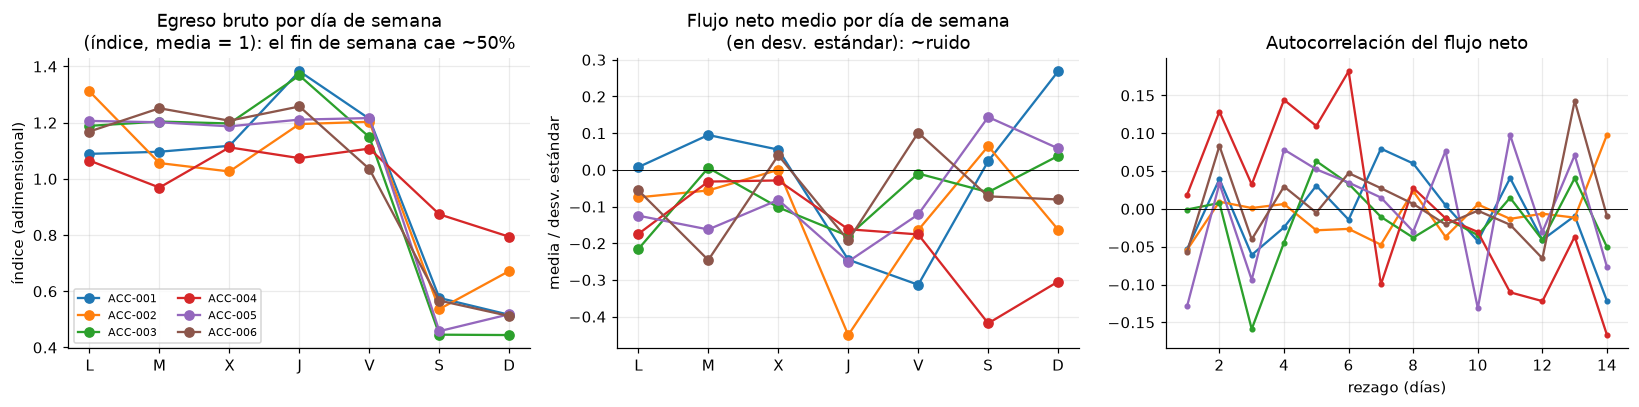

In [16]:
fig = plots.fig_flow_structure(panel); plt.show()

Los flujos **brutos** sí tienen estacionalidad semanal fuerte (el fin de semana cae ~50%), pero como ingresos y egresos caen juntos, el flujo **neto** tiene
media casi plana por día de semana y autocorrelación ≈ 0. Implicación: hay poca señal en la *media* del neto; lo que se puede modelar bien es su **distribución**
(escala por tipo de día, acumulación en el horizonte, deriva).

## 2.3 Forecast probabilístico: escalera de modelos con backtest walk-forward

Escalera del spec, en orden: **(1) naive estacional semanal** (baseline obligatorio) → **(2) ETS aditivo (período 7)** → **(3) SARIMAX** con dummies de día de semana y fin de mes.
Se añade una **referencia de cordura**, `empirical`: pronóstico puntual 0 y distribución = bootstrap i.i.d. de los flujos históricos por tipo de día (hábil/fin de semana). Si nadie le gana, la media no tiene señal.
Distribución predictiva por **bootstrap de residuos**; ventana expansiva; **origen diario**; horizontes 7 y 14 días; sin lookahead (hay un test que lo verifica).

,MAE diario / baseline,pinball diario / baseline,MAE acumulado / baseline,pinball acumulado / baseline,cobertura p5–p95 (acumulado),cobertura p5–p95 (diaria)
model,,,,,,
empirical,0.68,0.69,0.68,0.66,0.93,0.93
seasonal_naive,1.00,1.00,1.00,1.00,0.90,0.92
ets,0.72,0.73,0.74,0.74,0.93,0.93
sarimax,0.72,0.71,0.72,0.67,0.93,0.92


warnings de convergencia registrados (no silenciados): {'empirical': 0, 'seasonal_naive': 0, 'ets': 0, 'sarimax': 0}


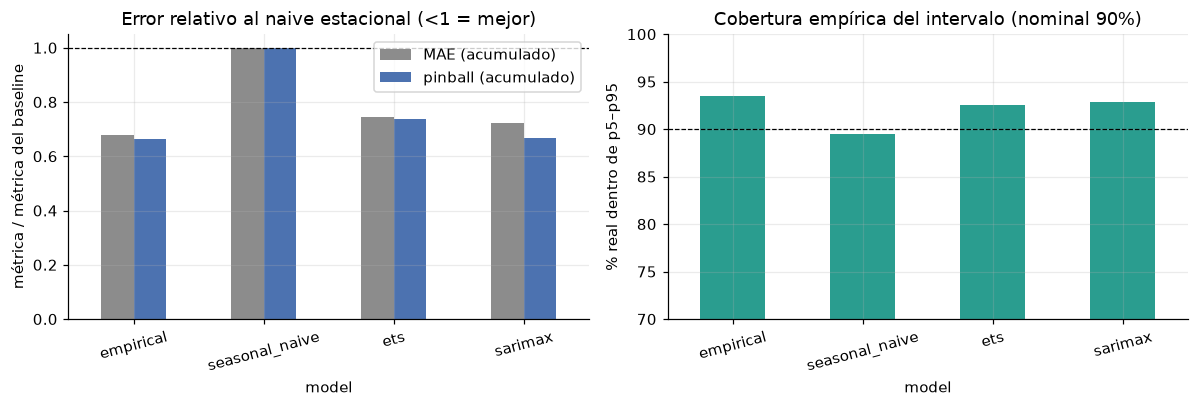


Modelo elegido por métrica (el más simple que gana al baseline y queda a ≤2% del mejor pinball acumulado): 'empirical'


In [17]:
scores, wf = F.compare_models(flows)
chosen, summary = F.select_model(scores)
display(summary.rename(columns={
    "mae_daily_rel": "MAE diario / baseline", "pinball_daily_rel": "pinball diario / baseline",
    "mae_cum_rel": "MAE acumulado / baseline", "pinball_cum_rel": "pinball acumulado / baseline",
    "cover_cum": "cobertura p5–p95 (acumulado)", "cover_daily": "cobertura p5–p95 (diaria)"}))
print("warnings de convergencia registrados (no silenciados):", {m: r["n_warnings"] for m, r in wf.items()})
fig = plots.fig_model_skill(summary); plt.show()
print(f"\nModelo elegido por métrica (el más simple que gana al baseline y queda a ≤{cfg.MODEL_TOLERANCE:.0%} del mejor pinball acumulado): {chosen!r}")

**Lectura.** Los tres modelos ganan claramente al naive estacional (**~26–34% menos pinball acumulado**), y no por sofisticación: el naive *inyecta ruido* (repite el flujo neto de hace una semana, que casi no tiene señal, y duplica la varianza del error).
Pero **ni ETS ni SARIMAX le ganan a `empirical`** en pinball acumulado (la pérdida que importa para dimensionar un buffer) y su cobertura no es mejor. Por regla de decisión (*el más simple que gane al baseline*), **se queda `empirical`**.
Es un resultado incómodo pero honesto: **en estos datos la media del flujo neto no es predecible más allá de su deriva histórica; el valor está en la distribución calibrada**, no en el punto.

In [18]:
rel = F.skill_vs_baseline(scores)
cols = ["account_id", "h", "mae_cum", "mae_cum_rel", "pinball_cum", "pinball_cum_rel", "cover_daily", "cover_cum", "below_p5_cum", "above_p95_cum"]
tab = rel[rel["model"] == chosen][cols].set_index(["account_id", "h"])
display(tab.rename(columns={"mae_cum_rel": "MAE / baseline", "pinball_cum_rel": "pinball / baseline"}))
by_h = scores[scores["model"] == chosen].groupby("h")[["cover_daily", "cover_cum"]].mean()
display(by_h)
print(f"Cobertura empírica del intervalo p5–p95 (esperado ≈ 90%): diaria {scores[scores.model==chosen].cover_daily.mean():.1%}, "
      f"acumulada {scores[scores.model==chosen].cover_cum.mean():.1%}. Sobre el 90% nominal ⇒ ligeramente conservador (buffers algo holgados, del lado seguro).")

mae_cum  MAE / baseline   pinball_cum  pinball / baseline  cover_daily  cover_cum  below_p5_cum  above_p95_cum
account_id h                                                                                                                       
ACC-001    7  135,851,991.24            0.69 43,900,486.61                0.72         0.87       0.90          0.05           0.05
           14 200,816,478.21            0.54 64,851,570.82                0.53         0.87       0.89          0.07           0.05
ACC-002    7        6,847.55            0.73      2,058.04                0.68         0.93       0.94          0.05           0.02
           14       9,900.57            0.65      2,844.02                0.57         0.93       0.95          0.04           0.01
ACC-003    7   99,450,849.99            0.69 31,147,833.24                0.67         0.88       0.92          0.06           0.02
           14 146,488,568.83            0.61 44,146,568.77                0.55         0.89       0.90          0.06           0.04
ACC-004    7    2,069,873.91            0.71    803,824.02                0.75         0.99       0.99          0.01           0.00
           14   3,106,893.16            0.63  1,268,179.41                0.73         0.99       1.00          0.00           0.00
ACC-005    7    4,297,835.71            0.78  1,300,329.31                0.74         0.94       0.91          0.08           0.01
           14   6,507,568.86            0.66  1,962,610.11                0.62         0.94       0.92          0.07           0.01
ACC-006    7        7,475.88            0.76      2,413.45                0.74         0.97       0.95          0.02           0.03
           14      11,517.85            0.71      3,709.28                0.67         0.97       0.93          0.05           0.02

,cover_daily,cover_cum
h,,
7,0.93,0.94
14,0.93,0.93


Cobertura empírica del intervalo p5–p95 (esperado ≈ 90%): diaria 93.1%, acumulada 93.5%. Sobre el 90% nominal ⇒ ligeramente conservador (buffers algo holgados, del lado seguro).


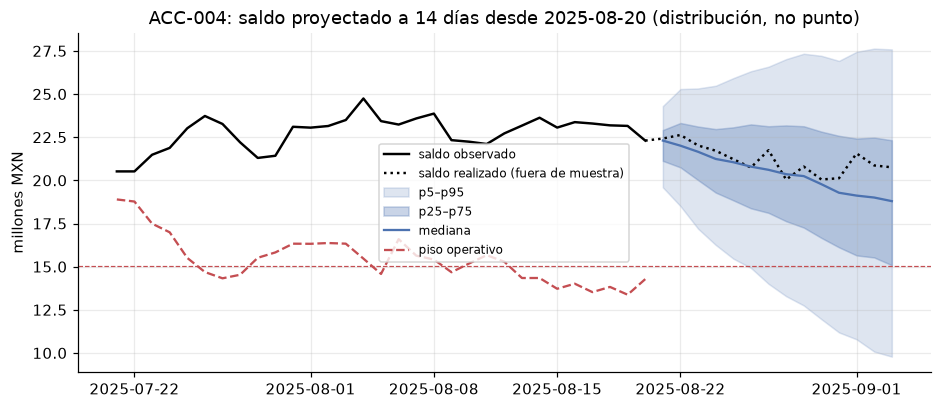

In [19]:
t_fan = list(book.dates).index(pd.Timestamp("2025-08-20"))
fig = plots.fig_fan(book, store, t_fan, "ACC-004"); plt.show()

## 2.4 El piso operativo: qué K es defendible

*K* define qué es un faltante. Un piso que el sistema **en su conjunto** no puede satisfacer convierte el problema en uno de *fondeo*, no de *rebalanceo*.
Excedente agregado (USD eq) = Σ(saldo − piso) sobre las 6 cuentas, en la ventana del backtest:

In [20]:
D.system_surplus_by_k(panel)

,excedente_agregado_min_USD,excedente_agregado_final_USD,dias-cuenta bajo el piso (sin intervenir)
K (días de egresos),,,
20,"2,956,775.30","4,104,067.88",1
25,"1,507,403.85","2,995,312.53",33
28,"637,780.97","2,330,059.33",99
30,"58,032.39","1,886,557.19",218


Con **K = 30** el excedente agregado en el día más ajustado es de ~USD 58 mil sobre ~USD 8,5 M de saldos: la liquidez total apenas alcanza la suma de pisos, y los faltantes
son estructurales. Con **K = 25** el mínimo es ~USD 1,5 M. Se adopta **K = 25** (día-egreso, igual para operativas y reservas) por **solvencia agregada**, y **K = 30 se corre como sensibilidad** (2.8), donde se ve exactamente ese límite. Es una **[DECISIÓN HUMANA]** que Tesorería debe confirmar.

## 2.5 Capa 1 — Política de cuantil (la que se explica a Tesorería)

**Regla.** Para cada cuenta se proyecta el saldo de los próximos 14 días (saldo + flujo neto simulado + abonos ya en tránsito). Si el **cuantil p5** de esa proyección cae bajo el piso en un día alcanzable
por una transferencia nueva (`t+1+lag`), se cubre la diferencia (más un día de egresos de holgura). El buffer no es una cifra inventada: es **cuánto puede caer el saldo con 95% de confianza**.
El donante debe seguir sobre **su propio** piso (+5 días de egresos de histéresis, para no donar hoy lo que mañana necesitará). Prioridad: destino operativo antes que reserva; donante reserva antes que operativo, misma moneda antes que cross (0,04% y lag ≤1 vs ≈0,27% y lag 3).

Ejemplo real: **corte 2025-09-26** (último día con siguiente día de datos).

In [21]:
t_cut = list(book.dates).index(pd.Timestamp("2025-09-26"))
qpol = P.QuantilePolicy()
ctx = B.context_at(book, store, t_cut)
display(qpol.diagnostic(ctx))
plan_b = P.plan_to_frame(qpol.decide(B.context_at(book, store, t_cut)), ctx)
display(plan_b)

,moneda,tipo,saldo_hoy,piso,p5_minimo_14d,primer_dia_bajo_piso,excedente_donable
cuenta,,,,,,,
ACC-001,COP,operational,"2,172,487,717.48","1,776,168,682.12","1,717,298,168.87",2025-10-09,0.00
ACC-002,USD,operational,"75,259.49","78,777.93","48,611.00",2025-09-27,0.00
ACC-003,COP,reserve,"3,023,644,033.01","1,733,114,068.79","2,655,536,105.86",None,"575,799,223.30"
ACC-004,MXN,operational,"18,784,842.09","16,771,188.40","7,236,646.35",2025-09-27,0.00
ACC-005,MXN,reserve,"108,043,651.47","65,619,991.43","93,984,745.42",None,"15,240,755.70"
ACC-006,USD,reserve,"145,543.73","98,495.07","119,094.48",None,900.40


,corte,origen,destino,moneda_origen,monto,fecha_ejecucion,liquidacion_esperada,fee_estimado,moneda_destino,monto_recibido,fx_usada,motivo
0,2025-09-26,ACC-005,ACC-004,MXN,"10,205,389.59",2025-09-27,2025-09-28,"4,082.16",MXN,"10,205,389.59",MXN/MXN = 1,"p5 del saldo de ACC-004 cae a 7,236,646 MXN (piso 16,771,188); primer faltante proyectado 2025-09-27, cubre el 2025-10-10; donante ACC-0..."
1,2025-09-26,ACC-005,ACC-002,MXN,"614,574.70",2025-09-27,2025-09-30,"1,659.35",USD,"33,318.05",USD/MXN = 0.0542132,"p5 del saldo de ACC-002 cae a 48,611 USD (piso 78,778); primer faltante proyectado 2025-09-27, cubre el 2025-10-10; donante ACC-005 con ..."
2,2025-09-26,ACC-003,ACC-001,COP,"129,917,260.53",2025-09-27,2025-09-28,"51,966.90",COP,"129,917,260.53",COP/COP = 1,"p5 del saldo de ACC-001 cae a 1,717,298,169 COP (piso 1,776,168,682); primer faltante proyectado 2025-10-09, cubre el 2025-10-10; donant..."


El plan trae lo exigido: origen, destino, monto, moneda, fecha de ejecución, liquidación esperada, fee estimado y **motivo**. Verificado por tests: nunca cubre una moneda con otra sin aplicar FX
(`monto_recibido = monto × FX`), nunca propone una transferencia cuyo abono llegue después del día que pretende cubrir, y el donante conserva su piso.

**Tabla de supuestos que acompaña al plan:**

In [22]:
cfg.assumptions_table()

,supuesto,valor,origen / nota
0,FX (unid. por USD),"{'USD': 1.0, 'MXN': 18.4457, 'COP': 3900.0}","[DECISIÓN HUMANA] MXN: FIX Banxico 26-sep-2025 = 18,4457. COP: aproximado ~3.900, pendiente de sustituir por la TRM oficial (Banco de la..."
1,Fee variable,"{'same_ccy': 0.0004, 'cross_ccy': 0.0027}","Observado en el log: misma moneda 0,04% fijo; cross 0,15-0,40%"
2,Lag observado,"{'same_ccy': {0: 20, 1: 5}, 'cross_ccy': {1: 37, 2: 57, 3: 26}}",Observado en el log
3,Lag de planificación,"{'same_ccy': 1, 'cross_ccy': 3}",p90 por tipo (conservador)
4,Costo fijo por operación (USD),25.0,[DECISIÓN HUMANA] no observable
5,Penalización por déficit,0.20% del déficit por cuenta-día,[DECISIÓN HUMANA] define el punto en la frontera
6,Ponderación penalización,"{'operational': 1.0, 'reserve': 0.5}",operativa > reserva como destino
7,Piso operativo,"{'operational': 25.0, 'reserve': 25.0} días de egresos medios (28d)",[DECISIÓN HUMANA] define qué es 'faltante'
8,Monto mínimo de transferencia,1.0 día(s) de egresos del destino,evita goteo de micro-operaciones
9,Horizonte de decisión,"14 días, reoptimización diaria",spec §7


## 2.6 Capa 2 — Optimización (la que se explica al data scientist)

MILP a horizonte rodante de 14 días, reoptimizado diariamente, resuelto con `scipy.optimize.milp` (HiGHS). La incertidumbre entra por **aproximación de escenarios (SAA)**: 40 trayectorias del forecast, y la penalización se aplica al **déficit esperado**.
Todo en USD equivalente (FX de config) y se reconvierte a moneda nativa al emitir el plan.

$$\min\ \sum_{i,j,d}\big(\phi_{ij}\,x_{ijd}+F\,z_{ijd}+\varepsilon d\,x_{ijd}\big)\;+\;\lambda\sum_a w_a\,\frac1S\sum_{k,s}u_{aks}$$

$$\text{s.a.}\quad u_{aks}\ \ge\ \text{piso}_a-\Big(b_{a}+\sum_{m\le k}n_{ams}+\text{tránsito}_{ak}-\sum_{j,d\le k}(1+\phi_{aj})x_{ajd}+\sum_{i,\,d+\ell_{ia}\le k}x_{iad}\Big),\quad u\ge 0$$

$$\sum_{j,d}(1+\phi_{aj})\,x_{ajd}\le\max(0,\,b_a-\text{piso}_a)\quad(\text{el donante no cae bajo su piso hoy}),\qquad m_j z_{ijd}\le x_{ijd}\le M z_{ijd},\ z\in\{0,1\}$$

- `x_ijd`: monto girado de *i* a *j* el día de solicitud *d*; llega en `d + ℓ_ij` (lag de planificación por tipo de par: p90 observado). `φ_ij`: fee por tipo (0,04% / 0,27%). `F`: costo fijo por operación **[DECISIÓN HUMANA]**. `λ`: penalización por USD·día de déficit **[DECISIÓN HUMANA]**. `w_a`: 1,0 operativa / 0,5 reserva. `m_j`: monto mínimo (1 día de egresos del destino). `ε`: desempate a favor de transferir antes.
- Solo se **ejecuta el día 1**; el resto del plan se recalcula mañana. Un **prefiltro exacto** evita resolver cuando la penalización esperada de una cuenta no supera ni el costo fijo de una operación (ninguna transferencia hacia ella puede ser rentable).
- El costo fijo y el monto mínimo son los que hacen que el modelo **agrupe** transferencias y **evite el goteo** de micro-operaciones que una regla proporcional haría.

Mismo corte, mismo forecast:

In [23]:
lp = O.LPPolicy()                                    # λ = DEFICIT_PENALTY_PER_DAY
today = lp.decide(B.context_at(book, store, t_cut))
plan_c = P.plan_to_frame(lp.last_plan, ctx)
display(plan_c)
print(f"Decisiones de hoy: {len(today)}. Casos en que hay faltante proyectado pero el MILP decide NO transferir: {len(lp.log)} cuenta(s) hoy.")

,corte,origen,destino,moneda_origen,monto,fecha_ejecucion,liquidacion_esperada,fee_estimado,moneda_destino,monto_recibido,fx_usada,motivo
0,2025-09-26,ACC-005,ACC-004,MXN,"9,690,319.60",2025-09-27,2025-09-28,"3,876.13",MXN,"9,690,319.60",MXN/MXN = 1,"MILP: reduce déficit esperado de ACC-004 (≈919,060 USD·día sin transferir, penalización esperada ≈ USD 1,838 > costo de operar); ACC-005..."
1,2025-09-26,ACC-006,ACC-002,USD,"22,165.47",2025-09-27,2025-09-28,8.87,USD,"22,165.47",USD/USD = 1,"MILP: reduce déficit esperado de ACC-002 (≈101,604 USD·día sin transferir, penalización esperada ≈ USD 203 > costo de operar); ACC-006 c..."


Decisiones de hoy: 2. Casos en que hay faltante proyectado pero el MILP decide NO transferir: 0 cuenta(s) hoy.


## 2.7 Backtest: tres políticas, mismos datos, mismo forecast, contrafactual explícito

- **A** — regla del squad reimplementada tal cual (diaria, sin estado, `transfer_today`), ejecutada **como la ejecutaría el banco**: el monto se gira en la moneda del donante y se convierte a FX.
  **A2** aísla cuánto de su fracaso es el defecto de moneda (D6): corrige *solo* eso.
- **B** — política de cuantil (barrido de α: p1, p5, p10, p25, p50).
- **C** — MILP (barrido de λ).
- **0** — no hacer nada (contrafactual).

Mismos números aleatorios (escenarios y lags realizados) para todas; ventana de evaluación 2025-03-02 → 2025-09-27 (210 días × 6 cuentas).

In [24]:
fr, runs = B.frontier(book, store)            # ~2 min: un MILP por día y por punto de λ
name_c = f"C: MILP λ={cfg.DEFICIT_PENALTY_PER_DAY:g}"
sel = ["0: sin transferencias", "A: regla del squad", "B: cuantil p5", name_c]
by_ccy, tot = B.compare({k: runs[k] for k in sel})
print("Métricas por moneda (nunca agregadas entre monedas; montos en la moneda nativa):")
display(by_ccy.set_index(["moneda", "politica"]).rename(columns={
    "dias_cuenta_en_faltante": "días-cuenta en faltante", "deficit_total": "déficit total (moneda·día)",
    "n_transferencias": "# transferencias (origen en la moneda)", "fees_totales": "fees totales (moneda)", "saldo_ocioso_prom": "saldo ocioso prom. (moneda)"}))
display(fr[["politica", "n_transferencias", "fees_usd", "costo_fijo_usd", "costo_total_usd", "deficit_usd_dias", "dias_cuenta_en_faltante", "volumen_usd"]].set_index("politica"))

Métricas por moneda (nunca agregadas entre monedas; montos en la moneda nativa):


,,días-cuenta en faltante,déficit total (moneda·día),# transferencias (origen en la moneda),fees totales (moneda),saldo ocioso prom. (moneda)
moneda,politica,,,,,
COP,0: sin transferencias,1,"53,182,675.54",0,0.00,"549,552,506.81"
MXN,0: sin transferencias,21,"95,263,561.31",0,0.00,"12,564,695.49"
USD,0: sin transferencias,11,"37,222.53",0,0.00,"21,345.02"
COP,A: regla del squad,56,"7,711,153,564.46",200,"4,973,902.90","316,908,738.74"
MXN,A: regla del squad,19,"93,928,138.36",0,0.00,"14,029,808.27"
USD,A: regla del squad,11,"37,117.56",0,0.00,"21,345.02"
COP,B: cuantil p5,0,0.00,16,"4,513,782.95","473,979,032.26"
MXN,B: cuantil p5,0,0.00,23,"42,652.34","12,589,801.26"
USD,B: cuantil p5,0,0.00,10,260.07,"31,134.51"


,n_transferencias,fees_usd,costo_fijo_usd,costo_total_usd,deficit_usd_dias,dias_cuenta_en_faltante,volumen_usd
politica,,,,,,,
0: sin transferencias,0,0.00,0.00,0.00,"5,215,399.43",33,0.00
A: regla del squad,200,"1,275.36","5,000.00","6,275.36","7,106,479.21",86,"472,355.45"
A2: squad + FX,31,666.20,775.00,"1,441.20","9,325,523.20",36,"1,244,502.94"
B: cuantil p1,55,"5,883.64","1,375.00","7,258.64","141,457.98",2,"5,026,283.75"
B: cuantil p5,49,"3,729.77","1,225.00","4,954.77",0.00,0,"4,404,232.22"
B: cuantil p10,28,"2,564.55",700.00,"3,264.55",0.00,0,"3,604,773.20"
B: cuantil p25,29,"2,415.04",725.00,"3,140.04","13,636.58",1,"3,160,760.11"
B: cuantil p50,12,777.96,300.00,"1,077.96","92,667.51",2,"1,900,402.90"
C: MILP λ=0.0005,13,"1,130.95",325.00,"1,455.95","2,322.90",2,"2,827,386.21"


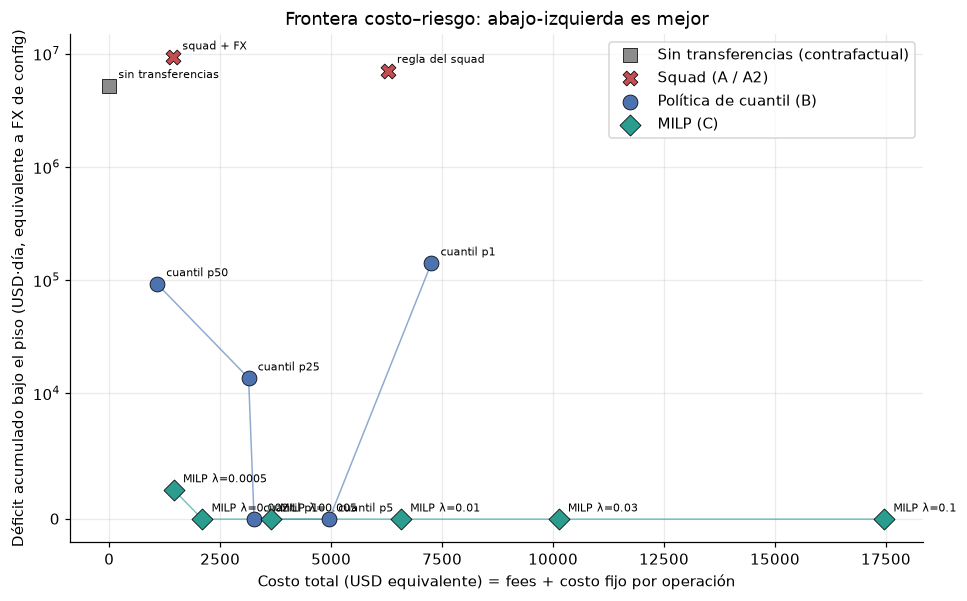

In [25]:
fig = plots.fig_frontier(fr); plt.show()

In [26]:
def dominated_by(row, table):
    better = table[(table.costo_total_usd <= row.costo_total_usd) & (table.deficit_usd_dias <= row.deficit_usd_dias)
                   & ((table.costo_total_usd < row.costo_total_usd) | (table.deficit_usd_dias < row.deficit_usd_dias))]
    return list(better.politica)

squad_row = fr[fr.politica == "A: regla del squad"].iloc[0]
none = fr[fr.politica == "0: sin transferencias"].iloc[0]
dom = dominated_by(squad_row, fr)
print(f"La regla del squad queda DOMINADA por {len(dom)} de las otras {len(fr) - 1} políticas, entre ellas 'no hacer nada'.")
print(f"  • vs. no hacer nada: {int(squad_row.dias_cuenta_en_faltante)} días-cuenta en faltante (contra {int(none.dias_cuenta_en_faltante)}) "
      f"y déficit {squad_row.deficit_usd_dias/none.deficit_usd_dias:.1f}× mayor, además de costar USD {squad_row.costo_total_usd:,.0f} en {int(squad_row.n_transferencias)} transferencias.")
print(f"  • Empeora el riesgo porque drena a ACC-003 (COP reserve) para 'cubrir' cuentas MXN/USD con pesos girados sin convertir, y se re-dispara cada día sobre el mismo faltante.")
a2 = fr[fr.politica == "A2: squad + FX"].iloc[0]
print(f"  • Corregir SOLO el FX (A2) no la salva: {int(a2.dias_cuenta_en_faltante)} días en faltante, déficit {a2.deficit_usd_dias:,.0f} USD·día. Umbral fijo + forecast sin horizonte + ignorar el tránsito siguen siendo el problema.")

La regla del squad queda DOMINADA por 8 de las otras 13 políticas, entre ellas 'no hacer nada'.
  • vs. no hacer nada: 86 días-cuenta en faltante (contra 33) y déficit 1.4× mayor, además de costar USD 6,275 en 200 transferencias.
  • Empeora el riesgo porque drena a ACC-003 (COP reserve) para 'cubrir' cuentas MXN/USD con pesos girados sin convertir, y se re-dispara cada día sobre el mismo faltante.
  • Corregir SOLO el FX (A2) no la salva: 36 días en faltante, déficit 9,325,523 USD·día. Umbral fijo + forecast sin horizonte + ignorar el tránsito siguen siendo el problema.


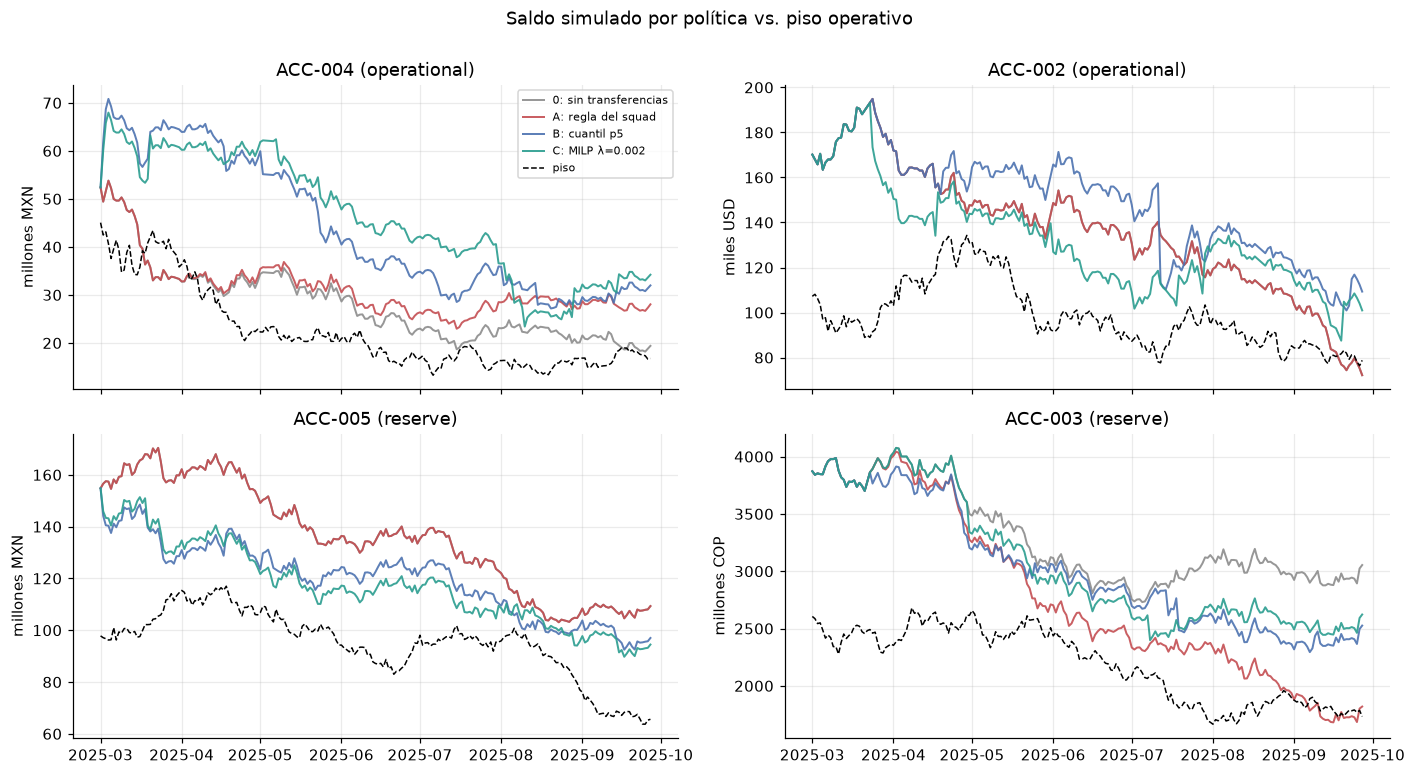

In [27]:
fig = plots.fig_policy_paths({k: runs[k] for k in sel}, book); plt.show()

**Lectura de la frontera.** (i) La regla del squad está en la esquina *peor*: más costo **y** más riesgo que no hacer nada. (ii) La política de cuantil (B) elimina los faltantes con un costo modesto; α es la perilla
(más α = menos colchón, más riesgo residual). (iii) El **MILP** llega al mismo riesgo (0) con **menos transferencias y menos costo** que B, porque *agrupa* operaciones (costo fijo) y elige por costo (misma moneda, 0,04%).
(iv) Subir λ por encima de la rodilla **solo compra costo sin bajar el déficit** (seguro de más). La elección de λ es una **decisión de Tesorería** (es el punto de la frontera donde quiere operar);
el default de `config.py` está en la rodilla, elegido *después* de ver esta misma frontera (en muestra: ver 2.9).

### El caso en que el MILP decide **no** transferir aunque hay faltante proyectado

In [28]:
log = pd.DataFrame(runs[name_c].log)
skip = log[log.penalizacion_esperada_usd < log.costo_minimo_de_cubrir_usd].copy()
skip["deficit_realizado_14d_usd"] = [B.realized_deficit_usd(runs[name_c], r.cuenta, r.fecha) for r in skip.itertuples()]
print(f"{len(skip)} decisiones cuenta-día con faltante proyectado en algún escenario donde el MILP NO transfiere porque la penalización esperada < costo mínimo de cubrirla.")
print(f"Déficit realmente ocurrido en los 14 días posteriores a esas decisiones: USD·día {skip.deficit_realizado_14d_usd.sum():,.0f} (suma) → no transferir fue correcto ex-post.")
ex = skip.sort_values("deficit_esperado_usd_dias", ascending=False).head(6)
display(ex[["fecha", "cuenta", "moneda", "prob_faltante_algun_dia", "deficit_esperado_usd_dias", "penalizacion_esperada_usd", "costo_minimo_de_cubrir_usd", "deficit_realizado_14d_usd"]].reset_index(drop=True))

324 decisiones cuenta-día con faltante proyectado en algún escenario donde el MILP NO transfiere porque la penalización esperada < costo mínimo de cubrirla.
Déficit realmente ocurrido en los 14 días posteriores a esas decisiones: USD·día 0 (suma) → no transferir fue correcto ex-post.


,fecha,cuenta,moneda,prob_faltante_algun_dia,deficit_esperado_usd_dias,penalizacion_esperada_usd,costo_minimo_de_cubrir_usd,deficit_realizado_14d_usd
0,2025-08-27,ACC-005,MXN,0.12,"32,316.57",32.32,32.70,0.00
1,2025-05-08,ACC-005,MXN,0.05,"32,223.54",32.22,32.76,0.00
2,2025-05-22,ACC-005,MXN,0.12,"30,176.54",30.18,31.25,0.00
3,2025-05-29,ACC-006,USD,0.55,"25,228.86",25.23,27.10,0.00
4,2025-07-26,ACC-005,MXN,0.05,"25,054.17",25.05,30.10,0.00
5,2025-08-15,ACC-005,MXN,0.12,"23,902.10",23.90,29.82,0.00


**Por qué es correcto.** Con `F` = USD 25 por operación, mover dinero cuesta *al menos* USD 25 más fees; si el déficit esperado, valorado a `λ` por USD·día, vale menos que eso, la operación destruye valor:
el beneficio esperado (≈ USD 25–32 en los ejemplos) no alcanza a pagar la operación (≈ USD 27–33): son casos borderline, con faltantes de baja magnitud. Una regla proporcional (o el cuantil puro) transferiría igual y pagaría el costo fijo por evitar una penalización menor que él. Ex-post, esos días no produjeron ningún faltante.

## 2.8 Sensibilidad

FX ±10% (el FX *real* de ejecución difiere del planificado en las monedas COP y MXN), lag forzado a 3 días (sin avisar al planificador), forecast degradado (sesgo optimista de +0,5σ diaria en el flujo neto) y piso de 30 días.

In [29]:
milp_transfers = pd.DataFrame([
    dict(origen=book.accounts[s.i], destino=book.accounts[s.j], moneda_origen=book.ccy[s.i], moneda_destino=book.ccy[s.j])
    for s, _ in runs[name_c].transfers
])
role_m = accounts.set_index("account_id")["account_type"]
milp_transfers["rol_origen"] = milp_transfers.origen.map(role_m)
milp_transfers["rol_destino"] = milp_transfers.destino.map(role_m)

print(f"{len(milp_transfers)} transferencias del MILP; {(milp_transfers.moneda_origen == milp_transfers.moneda_destino).mean():.0%} misma moneda.")
display(milp_transfers.groupby(["moneda_origen", "origen", "destino"]).size().rename("n").to_frame())
print("\nPor rol (origen -> destino):")
display(pd.crosstab(milp_transfers.rol_origen, milp_transfers.rol_destino))

22 transferencias del MILP; 100% misma moneda.


n
moneda_origen origen  destino   
COP           ACC-003 ACC-001  2
MXN           ACC-004 ACC-005  6
              ACC-005 ACC-004  8
USD           ACC-002 ACC-006  2
              ACC-006 ACC-002  4


Por rol (origen -> destino):


rol_destino,operational,reserve
rol_origen,,
operational,0,8
reserve,14,0


**Lectura: son 3 pools, no 22 pares libres.** Cada transferencia del MILP queda dentro de un par fijo — ACC-001↔ACC-003 (COP),
ACC-002↔ACC-006 (USD), ACC-004↔ACC-005 (MXN): la operativa y la reserva de su propia moneda. Nunca operativa→operativa ni
reserva→reserva, y nunca cruza de moneda. No es una restricción explícita del modelo: sale de minimizar costo con fees ~7× más
baratos dentro de la misma moneda (2.1), y en estos 210 días la reserva local siempre alcanzó. El problema real no es "elegir
entre 30 pares posibles entre 6 cuentas", son **3 pools independientes** con su propia operativa-reserva; el cruce de monedas
solo entraría como **fondeo de último recurso** si un pool entero se quedara sin liquidez (el MILP puede hacerlo si hace falta,
simplemente no le convino en este período). Así es como se lo explicaría a Tesorería en vez de "un optimizador con 22
transferencias entre 6 cuentas.

### 2.7b · La versión sencilla: cuantil + espera (política D)

A veces el saldo toca el piso pero el pronóstico dice que se va a recuperar, y mover dinero de todos modos solo genera fees. La política D es la B con una regla de espera. Una transferencia solicitada hoy llega en `lag` días y solo cubre faltantes de ese día en adelante, así que para cada cuenta con faltante proyectado (p5 bajo el piso) se pregunta:

1. **¿Sobra tiempo?** `holgura` = días entre lo que tarda en llegar el dinero y el primer día bajo el piso. Con al menos 1 día de holgura se puede esperar y solicitar más tarde sin llegar tarde.
2. **¿El pronóstico central se recupera?** La **mediana** proyectada se mantiene sobre el piso + 1 día de egreso en todos los días cubribles: el faltante solo existe en la cola de la distribución.

Si ambas se cumplen, **espera** y re-evalúa mañana (la reoptimización es diaria) dejando escrito el *último día para solicitar*. Si no, transfiere igual que B: mismos donantes, montos y margen. Es la regla explicable de lo que el MILP hace por costo.

In [30]:
res_d = B.simulate(book, P.WaitAwarePolicy(), store)
_, tot_d = B.compare({**{k: runs[k] for k in sel}, res_d.policy: res_d})
display(tot_d[["politica", "n_transferencias", "fees_usd", "costo_fijo_usd", "costo_total_usd", "deficit_usd_dias", "dias_cuenta_en_faltante", "volumen_usd"]].set_index("politica"))
print(f"Decisiones de esperar registradas por D: {len(res_d.log)}")
display(pd.DataFrame(res_d.log).groupby("cuenta").size().rename("esperas").to_frame().T)

,n_transferencias,fees_usd,costo_fijo_usd,costo_total_usd,deficit_usd_dias,dias_cuenta_en_faltante,volumen_usd
politica,,,,,,,
0: sin transferencias,0,0.00,0.00,0.00,"5,215,399.43",33,0.00
A: regla del squad,200,"1,275.36","5,000.00","6,275.36","7,106,479.21",86,"472,355.45"
B: cuantil p5,49,"3,729.77","1,225.00","4,954.77",0.00,0,"4,404,232.22"
C: MILP λ=0.002,22,"1,548.73",550.00,"2,098.73",0.00,0,"3,871,836.38"
D: cuantil p5 + espera,13,"2,230.32",325.00,"2,555.32","130,243.73",3,"3,362,817.98"


Decisiones de esperar registradas por D: 166


cuenta,ACC-001,ACC-002,ACC-003,ACC-004,ACC-005,ACC-006
esperas,4,66,2,43,42,9


**Lectura.** D mueve dinero **13 veces en lugar de 49** (B) y el costo baja de USD 4.955 a **USD 2.555 (−48%)**, pero deja
**3 días-cuenta en faltante** (superficiales: 0,0–0,5 días de egreso bajo el piso), donde B y el MILP llegan a 0. Más margen de
recuperación baja el faltante residual a 1 día-cuenta a cambio de más transferencias; ningún ajuste razonable llega a 0.

**Conclusión.** D captura casi todo el ahorro en costo pero no la seguridad. Su valor está en **identificar oportunidades y
explicarlas** (qué cuenta puede esperar y hasta cuándo), no en reemplazar al MILP: para cero faltantes la recomendación sigue
siendo C.

In [31]:
sens = B.sensitivity(panel, store)          # ~2 min
sens["pol"] = sens["politica"].str.split(":").str[0].map({"0": "0 sin transf.", "A": "A squad", "B": "B cuantil p5", "C": "C MILP"})
order = ["base", "FX +10%", "FX -10%", f"lag forzado {cfg.LAG_STRESS_DAYS}d", f"forecast sesgado +{cfg.SENSITIVITY_BIAS_SD}σ", "piso 30 días"]
piv = sens.pivot(index="escenario", columns="pol", values=["dias_cuenta_en_faltante", "deficit_usd_dias", "costo_total_usd", "n_transferencias"]).loc[order]
for m, title in [("dias_cuenta_en_faltante", "Días-cuenta en faltante"), ("deficit_usd_dias", "Déficit acumulado (USD·día)"), ("costo_total_usd", "Costo total (USD)"), ("n_transferencias", "# transferencias")]:
    print(title); display(piv[m])

Días-cuenta en faltante


pol,0 sin transf.,A squad,B cuantil p5,C MILP
escenario,,,,
base,33.00,86.00,0.00,0.00
FX +10%,33.00,86.00,0.00,0.00
FX -10%,33.00,86.00,0.00,0.00
lag forzado 3d,33.00,86.00,0.00,0.00
forecast sesgado +0.5σ,33.00,86.00,1.00,3.00
piso 30 días,218.00,346.00,107.00,60.00


Déficit acumulado (USD·día)


pol,0 sin transf.,A squad,B cuantil p5,C MILP
escenario,,,,
base,"5,215,399.43","7,106,479.21",0.00,0.00
FX +10%,"5,215,399.43","7,106,488.76",0.00,0.00
FX -10%,"5,215,399.43","7,106,467.55",0.00,0.00
lag forzado 3d,"5,215,399.43","7,151,342.14",0.00,0.00
forecast sesgado +0.5σ,"5,215,399.43","7,106,479.21",231.94,"7,097.90"
piso 30 días,"25,961,123.88","35,287,960.62","25,466,515.06","2,036,695.72"


Costo total (USD)


pol,0 sin transf.,A squad,B cuantil p5,C MILP
escenario,,,,
base,0.00,"6,275.36","4,954.77","2,098.73"
FX +10%,0.00,"6,275.36","3,796.13","2,098.73"
FX -10%,0.00,"6,275.36","4,723.39","2,098.73"
lag forzado 3d,0.00,"6,279.80","4,954.77","2,098.73"
forecast sesgado +0.5σ,0.00,"6,275.36","1,264.85",672.77
piso 30 días,0.00,"6,275.36","5,669.79","13,440.42"


# transferencias


pol,0 sin transf.,A squad,B cuantil p5,C MILP
escenario,,,,
base,0.00,200.00,49.00,22.00
FX +10%,0.00,200.00,38.00,22.00
FX -10%,0.00,200.00,44.00,22.00
lag forzado 3d,0.00,200.00,49.00,22.00
forecast sesgado +0.5σ,0.00,200.00,14.00,6.00
piso 30 días,0.00,200.00,65.00,137.00


- **FX ±10%:** sin efecto en el riesgo de B ni C. El MILP ni se inmuta: sus 22 transferencias son **todas de la misma moneda**, sin exposición a FX; es una ventaja del diseño (fee 0,04%), no del azar.
- **Lag forzado a 3 días:** sin faltantes: el planificador ya planifica al p90 por tipo de par, y el buffer del cuantil absorbe el resto.
- **Forecast sesgado (+0,5σ):** **es la sensibilidad que sí duele.** Aparecen faltantes en B y en C, y C —que confía más en el forecast para *no* transferir— es la más expuesta. Un forecast optimista degrada la política: por eso el monitoreo de sesgo/cobertura (Parte 5) es un control, no un adorno.
- **Piso de 30 días:** las tres políticas quedan con faltantes porque el sistema como un todo casi no alcanza (2.4): el faltante es de **fondeo**, no de rebalanceo. Ahí el MILP minimiza el daño (60 días en faltante contra 107 de B, y ~12× menos déficit; B casi no mejora sobre no hacer nada), pero ninguna política inventa liquidez. La regla del squad sigue siendo peor que no hacer nada.

## 2.9 Dónde puede seguir fallando

- **Quiebre estructural en los flujos:** el bootstrap usa el pasado (ventana expansiva); un cambio de régimen (los saldos cambian de tendencia en abril–mayo en varias cuentas) hace que los cuantiles reaccionen lento. La cobertura del backtest (~93%) es promedio, no garantía en el cambio.
- **FX sin fuente real:** el COP es aproximado y los flujos entran en USD equivalente solo para costear y para la frontera; el plan sale en moneda nativa, pero la conversión real la fija el banco.
- **Colas no modeladas:** el bootstrap no extrapola más allá del peor flujo observado; una salida extraordinaria de un tamaño nunca visto no está en la distribución.
- **El MILP sobreajustado a un forecast sesgado:** mostrado arriba; mitigación = bias/coverage monitoring y un piso de seguridad por encima del óptimo.
- **Lag asumido estacionario:** se planifica al p90 histórico (0–1 misma moneda, 1–3 cross); no hay garantía en feriados o cortes bancarios.
- **Datos:** 18 días-cuenta en cuarentena puenteados (`reliable=False`); si son eventos reales, el riesgo de faltante está subestimado. 5 días de flujos brutos imputados. El log de transferencias no cuadra con los saldos.
- **El flujo depende del saldo:** los egresos parecen escalar con el nivel (≈ 35 días de cobertura estable). Al mover saldo entre cuentas, los flujos *no* se reajustan en la simulación (supuesto de exogeneidad).
- **λ y `F` elegidos en muestra:** el punto de operación se fijó mirando la misma historia que se usa para evaluar. Sin validación fuera de muestra: es una limitación explícita, no un resultado.

---
# Parte 3 · Dos explicaciones de lo mismo

In [32]:
g = lambda n: fr[fr.politica == n].iloc[0]
r0, rA, rB, rC = g("0: sin transferencias"), g("A: regla del squad"), g(sel[2]), g(name_c)
cov = scores[scores.model == chosen]
sk = F.skill_vs_baseline(scores)
naive_gain = 1 - sk[sk.model == chosen].pinball_cum_rel.mean()
bias_row = sens[(sens.escenario == f"forecast sesgado +{cfg.SENSITIVITY_BIAS_SD}σ")].set_index("pol")
hard_row = sens[(sens.escenario == "piso 30 días")].set_index("pol")
n_meses = (len(book.dates) - cfg.MIN_TRAIN_DAYS) / 30.44   # duración real de la ventana de backtest

display(Markdown(f'''
## 3.1 Para el data scientist del squad

**Datos.** Tu pipeline descartaba el 17,6% de las filas y trataba 9 etiquetas como 9 monedas. El paquete corrige todo con la *identidad contable* `b[t]=b[t-1]+in−out`: elige el duplicado que cuadra (no promedia),
reconstruye nulos exactamente, repara solo firmas exactas (−1×, 10×; nunca `abs()`) y pone en **cuarentena marcada** lo inexplicable (6 episodios de 3 días). Panel: 6 × 270, 0 nulos, residuo de la identidad ≈ 0,01. Un test por cada corrección.

**Forecast.** Se modela el **flujo neto diario**, no el nivel: `saldo[t+h] = saldo[t] + Σ flujo`. Escalera con backtest walk-forward (origen diario, ventana expansiva, h = 7 y 14, sin lookahead con test):
naive estacional (baseline) → ETS → SARIMAX (+ una referencia `empirical`). Todos baten al baseline (~{naive_gain:.0%} menos pinball acumulado), pero **ninguno bate a `empirical`**: la media del neto no tiene señal explotable
(ACF ≈ 0; la estacionalidad semanal está en los flujos brutos, no en el neto). Se elige `{chosen}` por la regla *el más simple que gana al baseline*. La distribución sale de un **bootstrap de residuos por tipo de día**;
cobertura p5–p95 empírica: {cov.cover_daily.mean():.1%} diaria / {cov.cover_cum.mean():.1%} acumulada (nominal 90%: ligeramente conservador).

**Decisión.** *(B)* cuantil p5 del saldo proyectado a 14 días vs. un **piso = 25 días de egresos medios** (sin lookahead); donante con histéresis; prioridad operativa/reserva y misma moneda primero.
*(C)* **MILP** a horizonte rodante (SAA con 40 escenarios): minimiza `fees + F·#operaciones + λ·déficit esperado` con lag por tipo de par, donante ≥ su piso, monto mínimo y binaria de operación.
Costos y lag **calibrados del log por tipo de transferencia** (misma moneda: 0,04% y 0–1 d; cross: ≈0,27% y 1–3 d): el spec los agregaba en un solo número.

**Evaluación.** Backtest walk-forward contra contrafactual, mismos escenarios y lags para todas las políticas, métricas **por moneda** y frontera costo–riesgo (nunca un promedio de saldos).
Sobre {int(r0.dias_cuenta_en_faltante)} días-cuenta en faltante sin intervenir: squad **{int(rA.dias_cuenta_en_faltante)}** (peor que nada; USD {rA.costo_total_usd:,.0f}), cuantil p5 **{int(rB.dias_cuenta_en_faltante)}** (USD {rB.costo_total_usd:,.0f}),
MILP **{int(rC.dias_cuenta_en_faltante)}** (USD {rC.costo_total_usd:,.0f} en {int(rC.n_transferencias)} transferencias). El MILP también *decide no transferir* cuando `penalización esperada < costo de operar` (2.7).

**Dónde puede fallar.** (1) Quiebre estructural en los flujos: el bootstrap mira al pasado. (2) FX sin fuente real (COP aproximado) y exposición cross-moneda. (3) Colas no modeladas: no hay flujos peores que el peor observado.
(4) **MILP sobreajustado a un forecast sesgado**: con sesgo optimista de +{cfg.SENSITIVITY_BIAS_SD}σ el MILP pasa a {int(bias_row.loc['C MILP','dias_cuenta_en_faltante'])} días en faltante y el cuantil a {int(bias_row.loc['B cuantil p5','dias_cuenta_en_faltante'])}.
(5) Lag asumido estacionario (p90 histórico). (6) λ y F elegidos en muestra. (7) Con un piso de 30 días el sistema no tiene liquidez suficiente: es un problema de fondeo que ningún rebalanceo resuelve.

## 3.2 Para Tesorería

**En una frase:** el borrador anterior no protegía su caja —de hecho la dejaba peor que no hacer nada—; la propuesta elimina los faltantes simulados con un costo pequeño y explica cada movimiento.

- **Seguridad de caja.** Definimos "faltante" como quedar por debajo de **25 días de egresos** en una cuenta (nivel a confirmar por Ustedes). Repasando los últimos 7 meses *como si* cada regla hubiera operado: sin hacer nada habría **{int(r0.dias_cuenta_en_faltante)} días-cuenta** bajo ese nivel;
  con la regla del borrador, **{int(rA.dias_cuenta_en_faltante)}** (peor, porque movía pesos colombianos para tapar cuentas en otras monedas); con la propuesta, **{int(rC.dias_cuenta_en_faltante)}**.
- **Costo.** {int(rC.n_transferencias)} transferencias en {n_meses:.0f} meses, ≈ USD {rC.costo_total_usd:,.0f} en total (≈ USD {rC.costo_total_usd/n_meses:,.0f}/mes), moviendo ≈ USD {rC.volumen_usd/1e6:,.1f} M. Todo se mueve **dentro de la misma moneda** (comisión 0,04%, llega en 0–1 día), no entre monedas (≈0,27%, hasta 3 días).
  La propuesta también **prefiere no mover** cuando el faltante esperado es menor que el costo de moverlo.
- **Cada movimiento viene con su razón**: de dónde, a dónde, cuánto, cuándo se ejecuta, cuándo llega, cuánto cuesta y por qué.
- **Riesgo que queda.** (a) Si el pronóstico es sistemáticamente optimista, aparecen faltantes (en la prueba de estrés: {int(bias_row.loc['C MILP','dias_cuenta_en_faltante'])} días); (b) si la liquidez *total* no alcanza para el nivel mínimo elegido —con 30 días pasa—,
  mover dinero entre cuentas no basta y hace falta fondeo externo; (c) seis episodios de datos de 3 días que no pudimos explicar (¿reales o errores de registro?); (d) el tipo de cambio usado es aproximado.
- **Lo que sigue necesitando criterio humano:** el nivel mínimo por cuenta; el tipo de cambio oficial; cuánto riesgo aceptar (dónde operar en la frontera costo–riesgo); la aprobación de transferencias grandes; y qué hacer con los episodios sin explicar.
'''))


## 3.1 Para el data scientist del squad

**Datos.** Tu pipeline descartaba el 17,6% de las filas y trataba 9 etiquetas como 9 monedas. El paquete corrige todo con la *identidad contable* `b[t]=b[t-1]+in−out`: elige el duplicado que cuadra (no promedia),
reconstruye nulos exactamente, repara solo firmas exactas (−1×, 10×; nunca `abs()`) y pone en **cuarentena marcada** lo inexplicable (6 episodios de 3 días). Panel: 6 × 270, 0 nulos, residuo de la identidad ≈ 0,01. Un test por cada corrección.

**Forecast.** Se modela el **flujo neto diario**, no el nivel: `saldo[t+h] = saldo[t] + Σ flujo`. Escalera con backtest walk-forward (origen diario, ventana expansiva, h = 7 y 14, sin lookahead con test):
naive estacional (baseline) → ETS → SARIMAX (+ una referencia `empirical`). Todos baten al baseline (~34% menos pinball acumulado), pero **ninguno bate a `empirical`**: la media del neto no tiene señal explotable
(ACF ≈ 0; la estacionalidad semanal está en los flujos brutos, no en el neto). Se elige `empirical` por la regla *el más simple que gana al baseline*. La distribución sale de un **bootstrap de residuos por tipo de día**;
cobertura p5–p95 empírica: 93.1% diaria / 93.5% acumulada (nominal 90%: ligeramente conservador).

**Decisión.** *(B)* cuantil p5 del saldo proyectado a 14 días vs. un **piso = 25 días de egresos medios** (sin lookahead); donante con histéresis; prioridad operativa/reserva y misma moneda primero.
*(C)* **MILP** a horizonte rodante (SAA con 40 escenarios): minimiza `fees + F·#operaciones + λ·déficit esperado` con lag por tipo de par, donante ≥ su piso, monto mínimo y binaria de operación.
Costos y lag **calibrados del log por tipo de transferencia** (misma moneda: 0,04% y 0–1 d; cross: ≈0,27% y 1–3 d): el spec los agregaba en un solo número.

**Evaluación.** Backtest walk-forward contra contrafactual, mismos escenarios y lags para todas las políticas, métricas **por moneda** y frontera costo–riesgo (nunca un promedio de saldos).
Sobre 33 días-cuenta en faltante sin intervenir: squad **86** (peor que nada; USD 6,275), cuantil p5 **0** (USD 4,955),
MILP **0** (USD 2,099 en 22 transferencias). El MILP también *decide no transferir* cuando `penalización esperada < costo de operar` (2.7).

**Dónde puede fallar.** (1) Quiebre estructural en los flujos: el bootstrap mira al pasado. (2) FX sin fuente real (COP aproximado) y exposición cross-moneda. (3) Colas no modeladas: no hay flujos peores que el peor observado.
(4) **MILP sobreajustado a un forecast sesgado**: con sesgo optimista de +0.5σ el MILP pasa a 3 días en faltante y el cuantil a 1.
(5) Lag asumido estacionario (p90 histórico). (6) λ y F elegidos en muestra. (7) Con un piso de 30 días el sistema no tiene liquidez suficiente: es un problema de fondeo que ningún rebalanceo resuelve.

## 3.2 Para Tesorería

**En una frase:** el borrador anterior no protegía su caja —de hecho la dejaba peor que no hacer nada—; la propuesta elimina los faltantes simulados con un costo pequeño y explica cada movimiento.

- **Seguridad de caja.** Definimos "faltante" como quedar por debajo de **25 días de egresos** en una cuenta (nivel a confirmar por Ustedes). Repasando los últimos 7 meses *como si* cada regla hubiera operado: sin hacer nada habría **33 días-cuenta** bajo ese nivel;
  con la regla del borrador, **86** (peor, porque movía pesos colombianos para tapar cuentas en otras monedas); con la propuesta, **0**.
- **Costo.** 22 transferencias en 7 meses, ≈ USD 2,099 en total (≈ USD 304/mes), moviendo ≈ USD 3.9 M. Todo se mueve **dentro de la misma moneda** (comisión 0,04%, llega en 0–1 día), no entre monedas (≈0,27%, hasta 3 días).
  La propuesta también **prefiere no mover** cuando el faltante esperado es menor que el costo de moverlo.
- **Cada movimiento viene con su razón**: de dónde, a dónde, cuánto, cuándo se ejecuta, cuándo llega, cuánto cuesta y por qué.
- **Riesgo que queda.** (a) Si el pronóstico es sistemáticamente optimista, aparecen faltantes (en la prueba de estrés: 3 días); (b) si la liquidez *total* no alcanza para el nivel mínimo elegido —con 30 días pasa—,
  mover dinero entre cuentas no basta y hace falta fondeo externo; (c) seis episodios de datos de 3 días que no pudimos explicar (¿reales o errores de registro?); (d) el tipo de cambio usado es aproximado.
- **Lo que sigue necesitando criterio humano:** el nivel mínimo por cuenta; el tipo de cambio oficial; cuánto riesgo aceptar (dónde operar en la frontera costo–riesgo); la aprobación de transferencias grandes; y qué hacer con los episodios sin explicar.


---
# Parte 4 · Formas de trabajo: dónde se usó IA y dónde no

**Herramienta:** Claude Code (asistente de programación con agente) sobre un spec escrito por mí que fija las decisiones de diseño (modelar flujo y no nivel, forecast con cuantiles, backtest walk-forward con contrafactual, modelos simples, LP/MILP clásico) y los criterios de aceptación por fase.

**Dónde sí, y cómo se verificó**
- *Capa de datos y pruebas:* el parser de fechas, la reconciliación por identidad contable y sus 13 tests unitarios; se contrastó el panel con el dataset limpio de un análisis previo (1.602 días idénticos al centavo) y con `validate_panel` (falla si el panel incumple el contrato).
- *Boilerplate:* estructura del repo, funciones de gráficos, ejecución del notebook, tablas de sensibilidad.
- *Exploración y redacción:* perfilado rápido de datos (lag, fee, escala de transferencias, correlaciones) y borradores de texto; **las cifras del texto se generan desde código**, no se escriben a mano.

**Dónde deliberadamente no (o solo con revisión humana)**
- *Los supuestos de negocio* (FX, piso operativo, costo fijo, penalización) están marcados **[DECISIÓN HUMANA]**: la IA propuso valores por defecto razonables y los dejó visibles en `config.py`; **no son decisiones validadas**, y el backtest los somete a sensibilidad para no depender de ellos.
- *La elección del punto de operación en la frontera* y *la lectura del backtest* (qué política recomendar y con qué caveats) son juicio humano; la IA calcula la frontera, no decide dónde operar.
- *El diagnóstico* se hizo **contrastando cada afirmación del spec contra los datos**, no aceptándola: así se detectó que el log de transferencias no aparece en los saldos, que los errores puntuales son 7 (no 4) más 6 episodios inexplicables, que el fee y el lag tienen dos regímenes (no uno) y que había 5 transferencias duplicadas.

**Dónde la IA (o el spec) se equivocó y se corrigió con evidencia**
- El spec daba por hecho que los residuos de la identidad se explican por transferencias liquidadas: **falso** (0 residuos, y las transferencias USD superan al mayor flujo diario).
- Primera versión de la política de cuantil: dejaba a las cuentas donar y recibir entre sí (**ping-pong**, 204 transferencias); el backtest lo reveló y se corrigió con histéresis del donante y prioridad reserva → operativa.
- Con K = 30 el problema deja de ser de rebalanceo (liquidez agregada ≈ suma de pisos): se detectó al medir la solvencia agregada y por eso K = 25 con K = 30 como sensibilidad.

---
# Parte 5 · De notebook a producción (media página)

**Pipeline de datos.** Origen: APIs bancarias / core de saldos y movimientos (no CSV), con contrato de datos versionado. Checks **bloqueantes** antes del modelo: formato de fecha (parser en cascada que falla ruidosamente), unicidad `(fecha, cuenta)`,
moneda vs. catálogo, **identidad contable** `b[t]=b[t-1]+in−out` (un residuo > 1 unidad detiene la corrida: es el detector que encontró todos los errores de este caso), rango plausible de saldos y FX, y **frescura** (dato del día presente para cada cuenta). Lo que falla queda en cuarentena marcada, nunca se descarta en silencio.

**Cadencia y orquestación.** Corrida **diaria post-cierre bancario** (decisión al cierre de `t` para solicitar en `t+1`). Airflow o Dagster: DAG *ingesta → checks → forecast → política → plan → aprobación*, con reintentos, SLA y alerta si falta una fuente. Reentrenamiento del forecast en cada corrida (barato: bootstrap sobre la ventana expansiva); reoptimización diaria del MILP (segundos).

**Monitoreo (¿se degrada el modelo?).** Pinball loss por cuenta y horizonte; **cobertura del intervalo p5–p95** (alerta si sale de 85–95%); **sesgo** del forecast (la sensibilidad que sí duele); PSI de los flujos netos vs. la ventana de entrenamiento (quiebre estructural); tasa de faltantes reales vs. predichos; fees ejecutados vs. presupuestados; **latencia real de liquidación** vs. el lag de planificación (p90); fracción de días con datos reconstruidos/cuarentena.

**Salvaguardas.** *Dry-run por defecto*: el sistema recomienda, no ejecuta. Tope por transferencia y tope diario agregado; **aprobación humana** por encima de un umbral; **kill switch**; límite de frecuencia por par de cuentas (evita ping-pong); reconciliación post-settlement (lo que llegó vs. lo planeado); bloqueo automático a modo manual si el monitoreo se degrada (cobertura, sesgo o frescura fuera de rango). Todo plan se archiva con su motivo y la tabla de supuestos vigente.

---
# Anexo técnico A · Estacionalidad, validación de nivel con `TimeSeriesSplit` y XGBoost

Material de soporte para el resumen de D4b–D4d en la Parte 1. No aporta una conclusión nueva sobre qué política usar —esa
evidencia es 2.3, con backtest walk-forward sobre el flujo neto— pero documenta *por qué* se descartó modelar el nivel
directamente y *por qué* un modelo no lineal con rezagos (XGBoost) tampoco cambia la recomendación.

### D4b · Estacionalidad semanal: identificarla antes de modelarla

La media móvil ignora la tendencia y la semana. Antes de meter estacionalidad en un modelo hay que **comprobar que existe y en qué serie**. El saldo es el flujo neto acumulado, así que su estacionalidad equivale a la del `net_flow`: se analizan `inflow`, `outflow` y `net_flow`.

La decisión la toma un test de hipótesis (**Kruskal-Wallis** entre los 7 días de la semana, nivel 1%). La fuerza STL, la autocorrelación en el rezago 7 y el periodograma son evidencia de apoyo. Ojo: STL extrae "estacionalidad" incluso del ruido (con n = 270 el ruido blanco da ~0,20, p95 ~0,29), así que un valor en ese rango no prueba nada.

In [33]:
from src import seasonality, tscv

rep = seasonality.weekly_seasonality_report(panel)
view = rep.assign(kruskal_p=rep["kruskal_p"].map("{:.2g}".format)).rename(columns={
    "fuerza_stl_7": "fuerza STL(7)", "acf_rezago_7": "ACF(7)", "banda_95": "±banda 95%",
    "periodo_dominante": "periodo dominante (días)", "kruskal_p": "p Kruskal (día de semana)", "semanal": "¿semanal?"})
display(view)
display(rep["semanal"].unstack("serie")[["inflow", "outflow", "net_flow"]].rename_axis(columns="¿patrón semanal significativo?"))

fuerza STL(7)  ACF(7)  ±banda 95%  periodo dominante (días) p Kruskal (día de semana)  ¿semanal?
account_id serie                                                                                                     
ACC-001    inflow             0.27    0.06        0.12                      6.92                    0.0011       True
           outflow            0.33    0.19        0.12                      7.11                   1.2e-06       True
           net_flow           0.22    0.08        0.12                      8.18                      0.15      False
ACC-002    inflow             0.24    0.09        0.12                      3.51                   9.1e-06       True
           outflow            0.22    0.06        0.12                      3.51                   9.1e-08       True
           net_flow           0.21   -0.05        0.12                      3.75                      0.42      False
ACC-003    inflow             0.61    0.45        0.12                      6.92                   1.2e-20       True
           outflow            0.58    0.46        0.12                      6.92                   5.5e-23       True
           net_flow           0.24   -0.01        0.12                      4.82                      0.89      False
ACC-004    inflow             0.25    0.21        0.12                    270.00                   2.1e-05       True
           outflow            0.04    0.15        0.12                    270.00                      0.53      False
           net_flow           0.00   -0.10        0.12                     30.00                      0.54      False
ACC-005    inflow             0.45    0.36        0.12                      6.92                   3.5e-14       True
           outflow            0.56    0.49        0.12                      6.92                     2e-22       True
           net_flow           0.17    0.01        0.12                      2.18                      0.82      False
ACC-006    inflow             0.39    0.32        0.12                      6.92                   7.4e-12       True
           outflow            0.35    0.30        0.12                      6.92                   8.2e-12       True
           net_flow           0.20    0.03        0.12                      2.13                      0.59      False

¿patrón semanal significativo?,inflow,outflow,net_flow
account_id,,,
ACC-001,True,True,False
ACC-002,True,True,False
ACC-003,True,True,False
ACC-004,True,False,False
ACC-005,True,True,False
ACC-006,True,True,False


**Lectura.**

- **Entradas y salidas sí tienen patrón semanal:** es significativo en 11 de 12 series (p entre 1e-23 y 1e-3). La única excepción es el egreso de ACC-004 (p = 0,53). El periodograma da ~6,9–7,1 días en ACC-001, 003, 005 y 006; en ACC-002 da 3,5 (un armónico de 7) y en ACC-004 gana la tendencia (270).
- **El flujo neto no lo tiene:** 0 de 6 significativas (p entre 0,15 y 0,89). Su fuerza STL (0,00–0,24) es lo que STL extrae del ruido blanco (~0,20), no una señal.
- **Por qué:** las entradas y las salidas caen juntas el fin de semana y se cancelan en el neto. Como el saldo es el neto acumulado, **el patrón semanal existe en los flujos brutos pero no en el saldo**.

Consecuencia para el modelo: un ETS del saldo con estacionalidad semanal no debería aportar; la estacionalidad identificada solo puede ayudar si se modela en `inflow` y `outflow` por separado. Se prueban las dos cosas abajo.

#### D4b-1 · Ver la estacionalidad antes de probarla

Antes de lanzar ADF/KPSS y el ACF/PACF conviene **mirar** las series. Para cada cuenta y para cada serie (saldo, entradas y salidas) se dibuja el perfil medio en tres ciclos:

- **Semanal:** día de la semana (lunes a domingo).
- **Quincenal:** día dentro de la quincena (1 a 15 en la primera, 16 a 31 pasan a 1 a 16 en la segunda), para ver efectos de día de pago.
- **Mensual:** día del mes (1 a 31).

Cada perfil es la desviación % respecto de la tendencia (media móvil centrada de 28 días; sin quitarla, la deriva del saldo taparía todo), con una banda de ±1,96 errores estándar y el p-valor de Kruskal-Wallis arriba a la derecha (en naranja si p < 0,01). **Si la banda cubre el 0 casi en todas las posiciones, no hay patrón distinguible del ruido.**

Límites: con ~9 meses, cada día de la semana tiene ~38 observaciones, cada posición de la quincena ~17 y cada día del mes ~9, así que el ciclo mensual es el menos fiable; y un ciclo por mes del año necesita más de un año de historia.

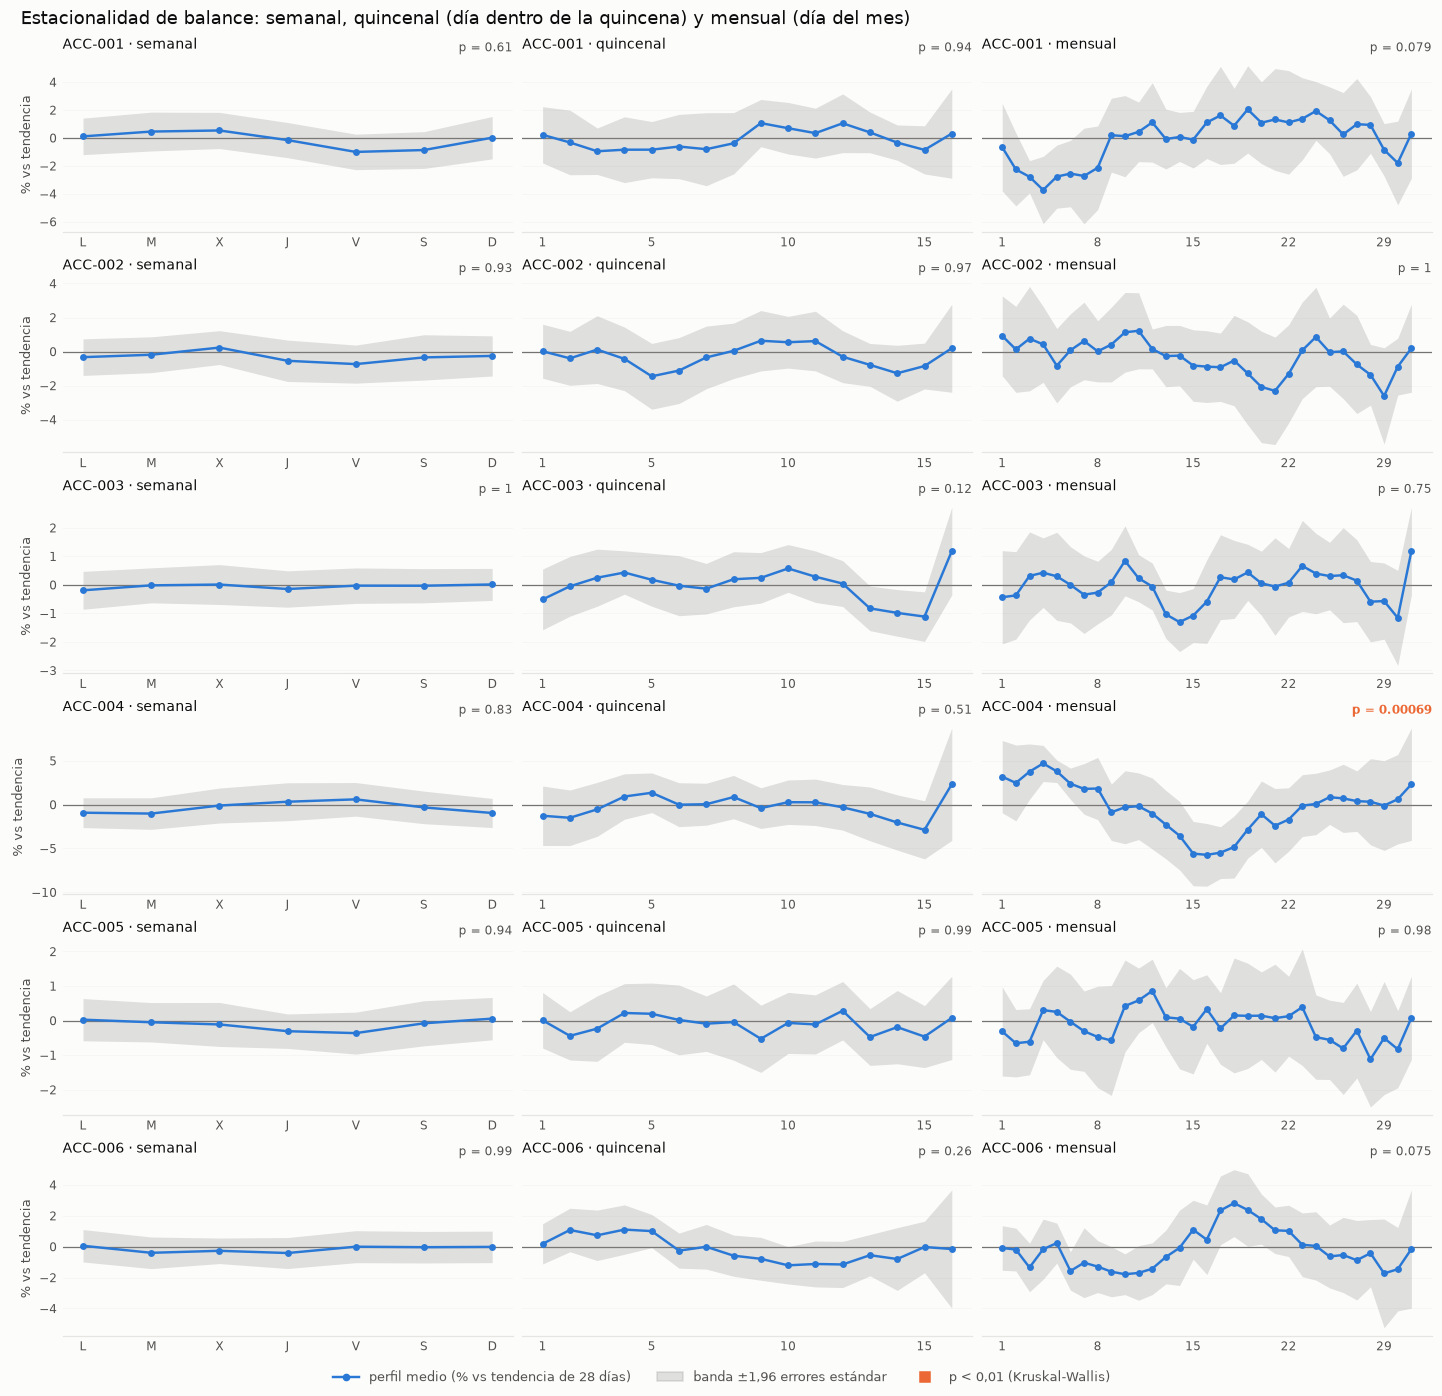

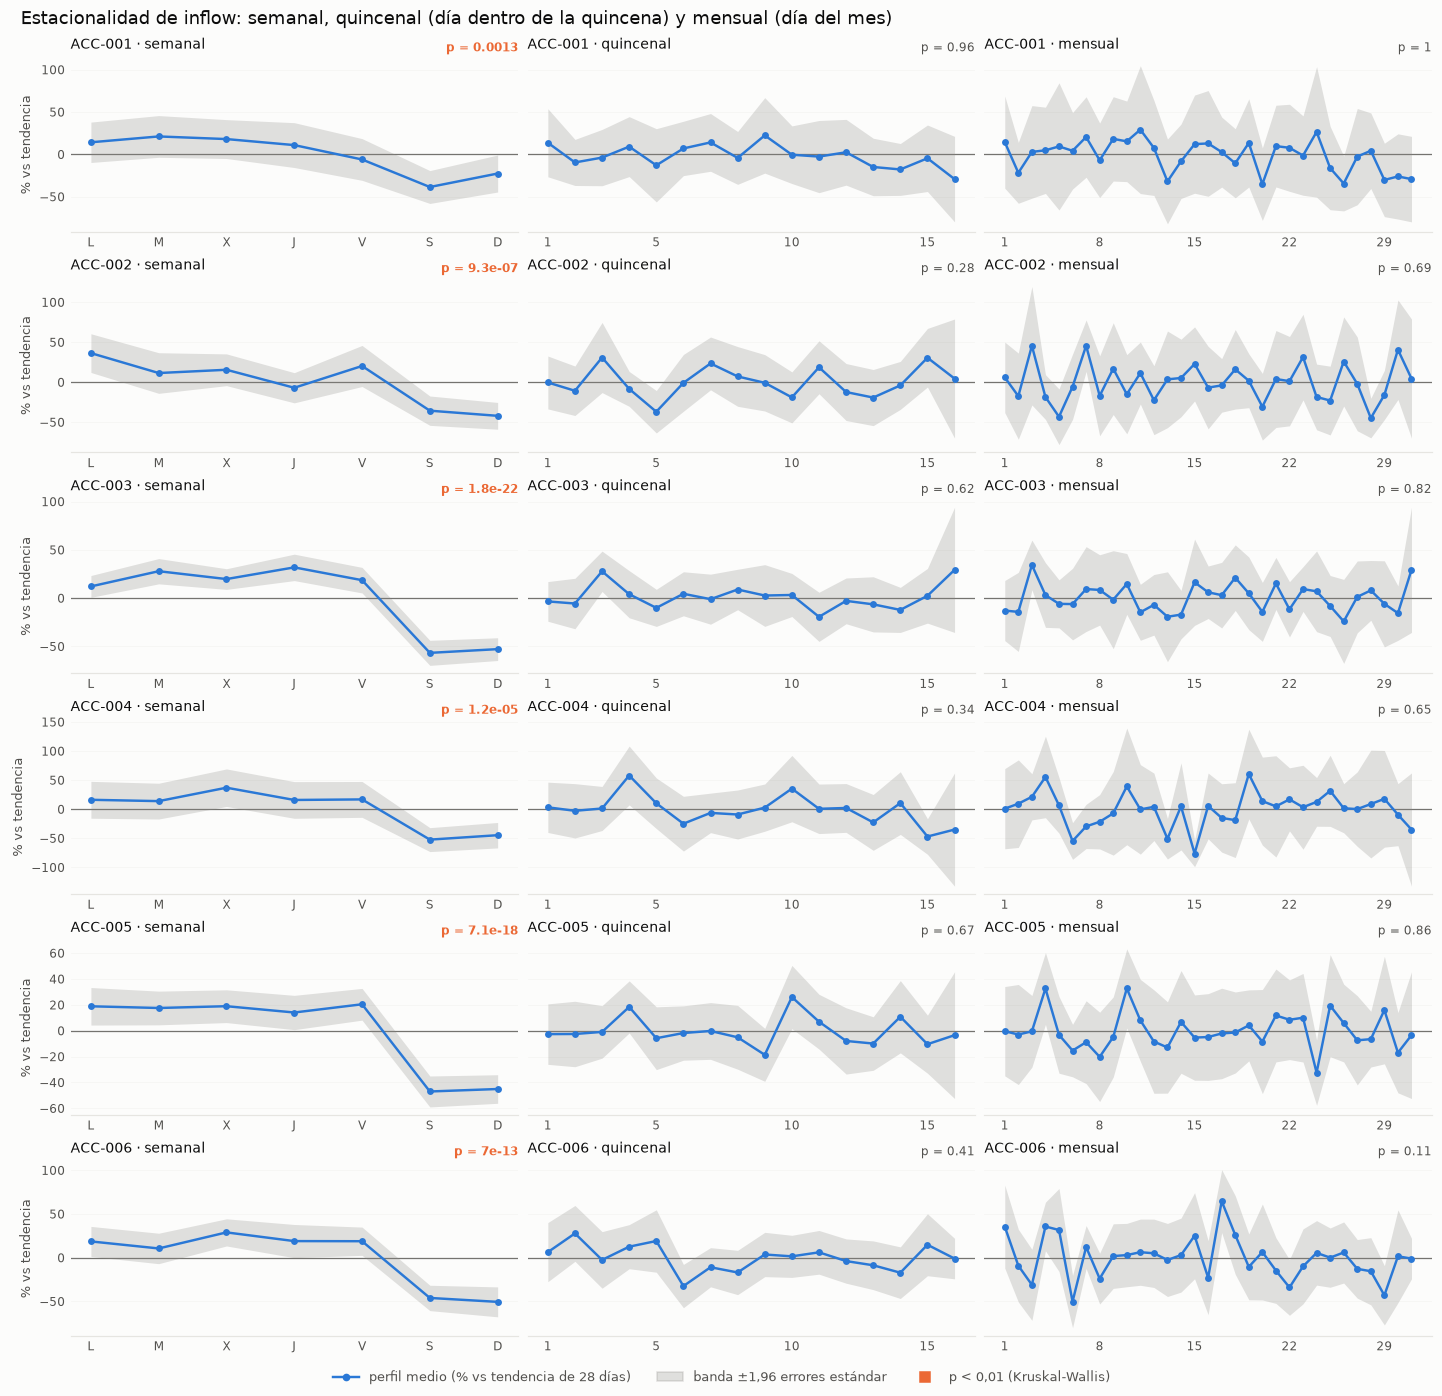

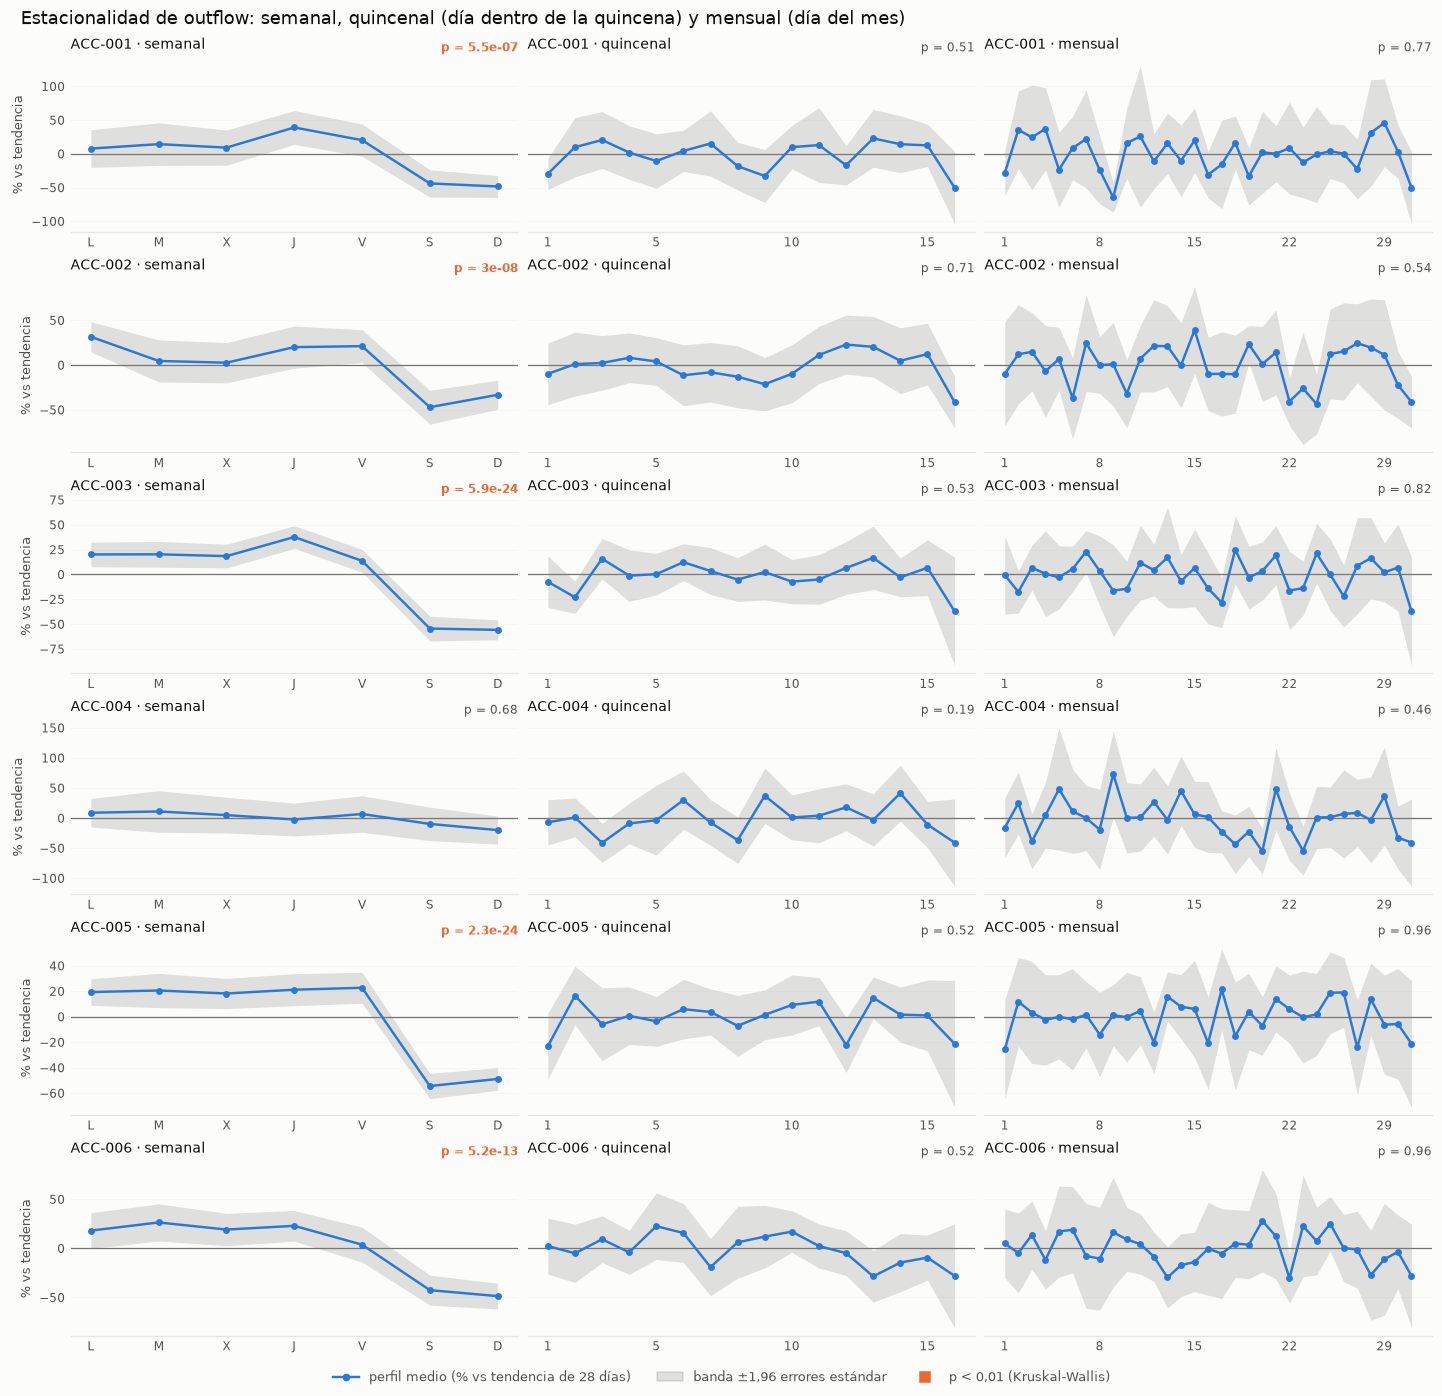

In [34]:
for serie in ("balance", "inflow", "outflow"):
    plots.fig_seasonality(panel, serie); plt.show()

In [35]:
pv = seasonality.cycle_pvalues(panel)
display(pv.map("{:.2g}".format).rename_axis(columns="p-valor (Kruskal-Wallis)"))
print(f"Ciclos quincenal y mensual con p < 0,01: {int((pv[['quincenal', 'mensual']] < 0.01).sum().sum())} de {pv[['quincenal', 'mensual']].size} pruebas "
      f"(por azar se esperaría ~{0.01 * pv[['quincenal', 'mensual']].size:.1f}).")

p-valor (Kruskal-Wallis)  semanal quincenal  mensual
account_id serie                                    
ACC-001    balance           0.61      0.94    0.079
           inflow          0.0013      0.96        1
           outflow        5.5e-07      0.51     0.77
ACC-002    balance           0.93      0.97        1
           inflow         9.3e-07      0.28     0.69
           outflow          3e-08      0.71     0.54
ACC-003    balance              1      0.12     0.75
           inflow         1.8e-22      0.62     0.82
           outflow        5.9e-24      0.53     0.82
ACC-004    balance           0.83      0.51  0.00069
           inflow         1.2e-05      0.34     0.65
           outflow           0.68      0.19     0.46
ACC-005    balance           0.94      0.99     0.98
           inflow         7.1e-18      0.67     0.86
           outflow        2.3e-24      0.52     0.96
ACC-006    balance           0.99      0.26    0.075
           inflow           7e-13      0.41     0.11
           outflow        5.2e-13      0.52     0.96

Ciclos quincenal y mensual con p < 0,01: 1 de 36 pruebas (por azar se esperaría ~0.4).


**Lectura.**

- **Semanal: es el único ciclo con señal clara, y solo en entradas y salidas.** El patrón es significativo (p < 0,01) en 11 de las 12 series de flujos; la excepción es el egreso de ACC-004 (p = 0,68). En el egreso, el fin de semana cae entre ~33% y ~55% respecto de la tendencia.
- **El saldo no tiene patrón semanal** (p entre 0,6 y 1,0 en las 6 cuentas): el efecto semanal de entradas y salidas se cancela en el neto y el saldo es su acumulado.
- **Quincenal: sin patrón.** Ninguna serie llega a p < 0,01 (el menor es 0,12, en el saldo de ACC-003) y la banda cubre el 0 en casi todas las posiciones. No se ve un efecto de día de pago.
- **Mensual: un único caso aislado.** El saldo de ACC-004 baja ~5% alrededor de los días 12 a 17 del mes (p = 0,0007). Es 1 de 36 pruebas quincenales y mensuales, cuando por azar se esperaría ~0,4, y coincide con la cuenta donde el notebook de diagnóstico ya encontró el componente de ~30 días más fuerte. Con ~9 observaciones por día es una pista, no una conclusión. Los saldos de ACC-001 y ACC-006 muestran ondulaciones suaves (p ≈ 0,08) que no alcanzan significancia.

**Qué esperar al lanzar ADF y el ACF/PACF:** el saldo se ve como una tendencia sin estacionalidad, así que lo esperable es que no sea estacionario en nivel; las entradas y salidas sí llevan un patrón semanal que hay que tratar (dummies de día de semana o un ETS estacional), y no hay ciclo quincenal ni mensual que modelar, con la excepción a vigilar de ACC-004.

#### D4b-2 · ACF / PACF: ¿hay que diferenciar? ¿dónde está la estacionalidad?

El test de día de semana dice **si** hay estacionalidad; el ACF/PACF dice **cómo se comporta** y cómo tratar el nivel. Se decide en dos pasos:

1. **Diferenciación (`d`).** Se diferencia solo si ADF no rechaza raíz unitaria **y** la diferencia no queda sobrediferenciada (ACF(1) de la diferencia por debajo de -0,25; diferenciar algo que no lo pedía da cerca de -0,5). KPSS se reporta como contraste.
2. **Estacionalidad.** Sobre la serie ya estacionaria (diferencia si `d = 1`; si no, el nivel menos la tendencia MSTL) se buscan picos en los rezagos 7, 14, 21 y 28. Solo se diferenciaría en el rezago 7 (`D = 1`) si el ACF estacional se mantiene alto **y** esa diferencia lo elimina; si lo deja cerca de -0,5, el patrón es determinístico y se modela con dummies, no con diferencias.

Se usa el panel ya limpio de F1. Sobre el crudo hay que enmascarar antes las lecturas corruptas, porque distorsionan el ACF (ver la sección 11 de `data_quality_diagnostics.ipynb`).

In [36]:
diff_t, seas_t, stationary = seasonality.acf_pacf_report(panel)
display(diff_t.rename(columns={
    "adf_p": "ADF p (nivel)", "kpss_p": "KPSS p (nivel)", "acf1_dif": "ACF(1) de la diferencia",
    "sobrediferenciada": "¿sobrediferenciada?", "kpss_confirma": "KPSS confirma"}).round(3))

ADF p (nivel)  KPSS p (nivel)  ACF(1) de la diferencia  ¿sobrediferenciada?  d  KPSS confirma
account_id serie                                                                                                 
ACC-001    balance           0.21            0.10                    -0.05                False  1          False
           inflow            0.00            0.10                    -0.47                 True  0           True
           outflow           0.00            0.10                    -0.42                 True  0           True
ACC-002    balance           0.98            0.01                    -0.05                False  1           True
           inflow            0.12            0.01                    -0.52                 True  0          False
           outflow           0.00            0.01                    -0.49                 True  0          False
ACC-003    balance           0.71            0.01                    -0.00                False  1           True
           inflow            0.09            0.01                    -0.27                 True  0          False
           outflow           0.09            0.01                    -0.27                 True  0          False
ACC-004    balance           0.07            0.01                     0.02                False  1           True
           inflow            0.00            0.01                    -0.48                 True  0          False
           outflow           0.00            0.01                    -0.49                 True  0          False
ACC-005    balance           0.96            0.01                    -0.13                False  1           True
           inflow            0.37            0.01                    -0.41                 True  0          False
           outflow           0.62            0.01                    -0.41                 True  0          False
ACC-006    balance           0.71            0.01                    -0.05                False  1           True
           inflow            0.31            0.01                    -0.45                 True  0          False
           outflow           0.35            0.01                    -0.38                 True  0          False

**Lectura.**

- **Saldo: se diferencia una vez (`d = 1`) en las 6 cuentas.** ADF no rechaza raíz unitaria (p de 0,07 a 0,98) y KPSS lo confirma en 5 de 6 (ACC-001 es la excepción, p = 0,10). La primera diferencia queda como ruido blanco (ACF(1) entre -0,13 y +0,02): el saldo se comporta como un **paseo aleatorio con deriva**.
- **Entradas y salidas: no se diferencian (`d = 0`) en ninguna de las 12 series.** Diferenciarlas las sobrediferencia (ACF(1) de la diferencia de -0,27 a -0,52, cerca del -0,5 teórico). KPSS rechaza estacionariedad en nivel en 10 de las 12, es decir, derivan lentamente; eso se resuelve quitándoles la tendencia (MSTL), no diferenciando.
- **Casos límite:** las entradas y salidas de ACC-003 (ADF p = 0,09; ACF(1) de la diferencia = -0,27, apenas por debajo del umbral de -0,25) son las decisiones más justas.

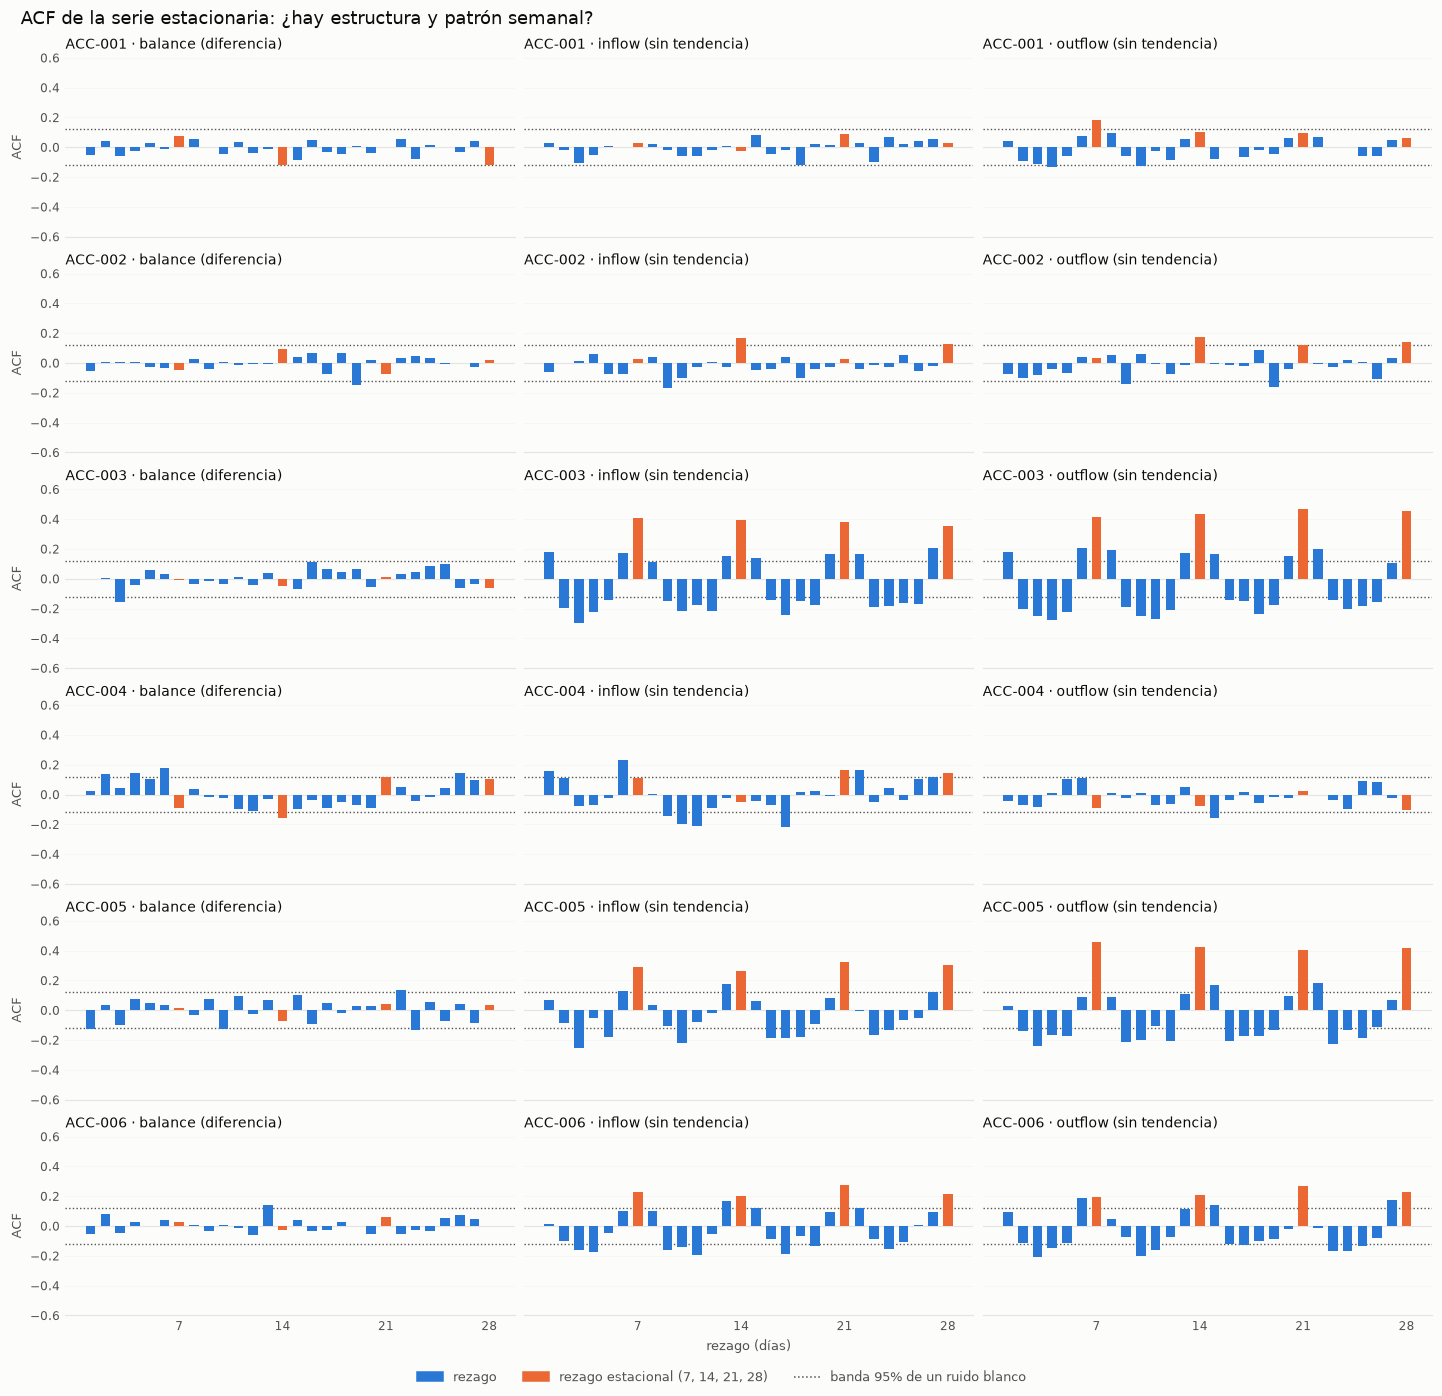

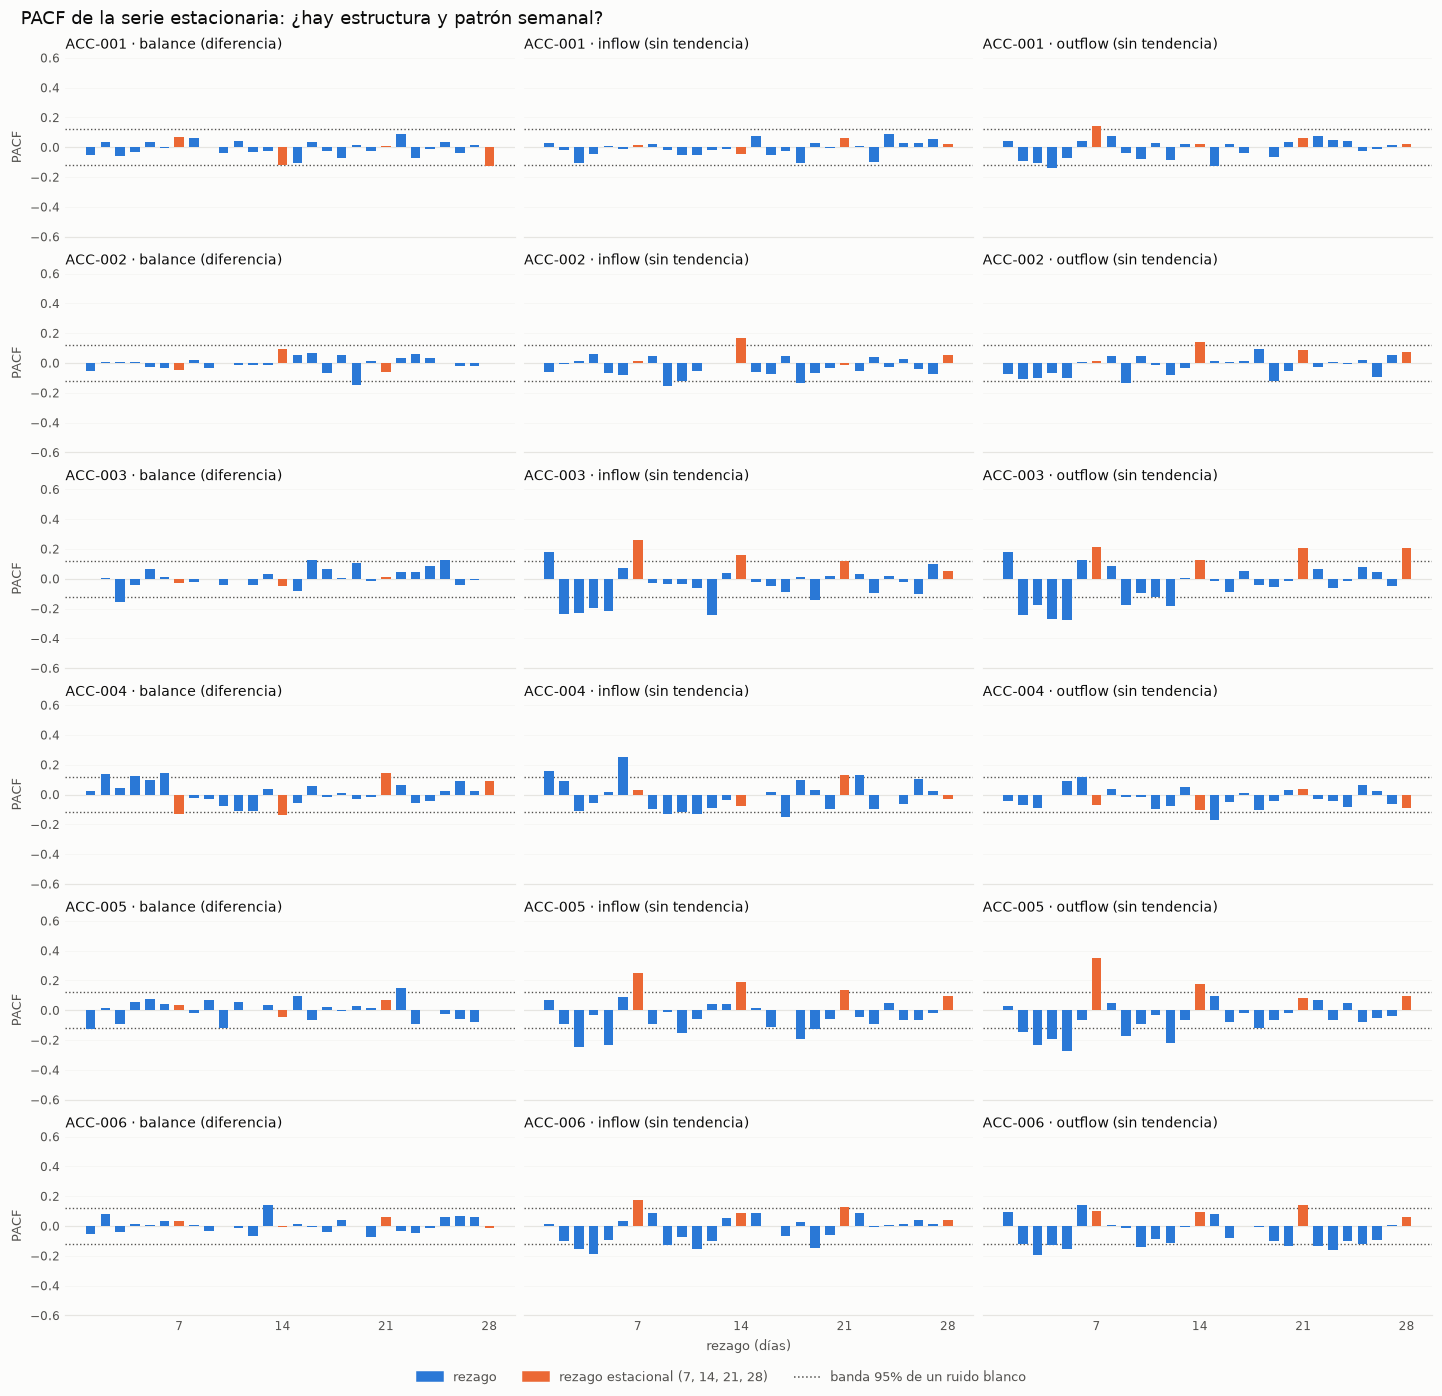

In [37]:
plots.fig_acf_pacf(stationary, diff_t, "acf"); plt.show()
plots.fig_acf_pacf(stationary, diff_t, "pacf"); plt.show()

**Lectura.** Las barras naranjas son los rezagos 7, 14, 21 y 28; las líneas punteadas, la banda de ruido blanco (±0,12).

- **Saldo (diferencia):** ACF y PACF dentro de la banda en casi todos los rezagos y sin picos estacionales: ni estructura AR/MA ni patrón semanal. La excepción es **ACC-004**, que conserva algo de autocorrelación (Ljung-Box p = 0,001).
- **Entradas y salidas de ACC-003, ACC-005 y ACC-006:** el ACF es un **"peine"**: picos en 7, 14, 21 y 28 con valores negativos entre ellos. Los picos casi no decaen (ACC-003 inflow: 0,41 / 0,40 / 0,38; ACC-005 outflow: 0,46 / 0,42 / 0,40), que es la firma de un **patrón semanal estable y determinístico** y no de una raíz unitaria estacional.
- El PACF es significativo en el rezago 7 en casi todas ellas, pero no es un corte limpio: también lo son algunos rezagos cortos, como es normal cuando el efecto de día de semana da forma a toda la semana.

In [38]:
display(seas_t.rename(columns={
    "acf_7": "ACF(7)", "pacf_7": "PACF(7)", "acf_14": "ACF(14)", "acf_21": "ACF(21)", "pico_7": "pico en 7",
    "picos_estacionales": "picos estacionales (de 4)", "ljung_box_p7": "Ljung-Box p (rezago 7)",
    "acf_7_tras_dif_7": "ACF(7) tras dif. en 7", "semanal": "¿semanal?"}).round(3))

d  ACF(7)  PACF(7)  ACF(14)  ACF(21)  pico en 7  picos estacionales (de 4)  Ljung-Box p (rezago 7)  ACF(7) tras dif. en 7  ¿semanal?  D
account_id serie                                                                                                                                           
ACC-001    balance  1    0.07     0.07    -0.12    -0.00       0.06                          0                    0.76                  -0.38      False  0
           inflow   0    0.03     0.02    -0.03     0.09       0.02                          0                    0.71                  -0.46      False  0
           outflow  0    0.18     0.14     0.10     0.10       0.17                          2                    0.00                  -0.44       True  0
ACC-002    balance  1   -0.05    -0.05     0.10    -0.07      -0.03                          0                    0.97                  -0.56      False  0
           inflow   0    0.03     0.02     0.17     0.02       0.09                          2                    0.65                  -0.57      False  0
           outflow  0    0.04     0.01     0.18     0.12       0.06                          3                    0.28                  -0.56      False  0
ACC-003    balance  1   -0.01    -0.03    -0.05     0.01      -0.02                          0                    0.28                  -0.48      False  0
           inflow   0    0.41     0.26     0.40     0.38       0.41                          4                    0.00                  -0.49       True  0
           outflow  0    0.41     0.22     0.43     0.47       0.42                          4                    0.00                  -0.52       True  0
ACC-004    balance  1   -0.09    -0.13    -0.16     0.12      -0.17                          1                    0.00                  -0.46      False  0
           inflow   0    0.11     0.03    -0.05     0.16       0.09                          1                    0.00                  -0.40      False  0
           outflow  0   -0.09    -0.07    -0.08     0.02      -0.14                          0                    0.09                  -0.49      False  0
ACC-005    balance  1    0.01     0.03    -0.07     0.04      -0.02                          0                    0.18                  -0.45      False  0
           inflow   0    0.29     0.25     0.26     0.32       0.32                          4                    0.00                  -0.49       True  0
           outflow  0    0.46     0.35     0.42     0.40       0.51                          4                    0.00                  -0.47       True  0
ACC-006    balance  1    0.03     0.03    -0.03     0.06       0.03                          0                    0.76                  -0.46      False  0
           inflow   0    0.23     0.17     0.20     0.27       0.23                          4                    0.00                  -0.48       True  0
           outflow  0    0.19     0.10     0.20     0.27       0.18                          4                    0.00                  -0.50       True  0

**Conclusión.** Un pico semanal cuenta si el ACF en el rezago 7 sobresale de sus vecinos más que la banda y al menos dos de los cuatro rezagos estacionales sobresalen.

- **Estacionalidad semanal en 7 de las 12 series de flujos:** entradas y salidas de ACC-003, ACC-005 y ACC-006, más la salida de ACC-001 (más débil, pico de 0,17). **Ningún saldo la tiene**, ni tampoco la entrada de ACC-001, ACC-002 y ACC-004.
- **Sin diferenciación estacional (`D = 0`) en ninguna serie.** Diferenciar en el rezago 7 deja el ACF(7) entre -0,38 y -0,57 (sobrediferencia) y los picos de arriba no decaen: el patrón semanal se modela con **dummies de día de semana o un ETS estacional**, no se elimina con diferencias.
- **Recomendación por tipo de serie:** saldo = `d = 1` sin estacionalidad (paseo aleatorio con deriva); entradas/salidas = `d = 0`, `D = 0` y efecto de día de semana donde la tabla lo marca.

Esto explica lo que sale en D4c: como el saldo no tiene estructura más allá de la deriva, "el último saldo" es muy difícil de superar y forzar una estacionalidad semanal sobre el saldo no mejora nada. El ACF/PACF es un detector conservador: el test de día de semana de D4b marca 11 de las 12 series de flujos y el ACF/PACF confirma las 7 más fuertes, mostrando además cómo es el patrón.

### D4c · Validación con `TimeSeriesSplit` y un forecast ETS

`TimeSeriesSplit` (scikit-learn) hace **ventana expansiva**: cada corte entrena con todo el pasado hasta un origen y prueba en el bloque de 14 días siguiente. Los bloques de prueba no se solapan y nunca preceden al entrenamiento. Se compara, contra el saldo real limpio:

- `squad_sin_limpiar` (la base) y `squad_limpio`: media de los últimos 14 (filas / días).
- `ultimo_saldo`: el saldo del origen sin cambios.
- `ets_nivel`: ETS del saldo con tendencia amortiguada, **sin** estacionalidad.
- `ets_nivel_semanal`: lo mismo con estacionalidad semanal **forzada**.
- `ets_flujos`: ETS de `inflow` y `outflow` por separado, con estacionalidad semanal solo si el test la identifica en el **entrenamiento** de ese corte.

Las razones son MAE del bloque sobre el MAE de `squad_sin_limpiar` (menor que 1 = mejor).

In [39]:
detail, info = tscv.cv_level_forecasts(panel, squad["balances"])
S = tscv.cv_summary(detail)

# cómo quedó el split: ventana expansiva, un bloque de prueba de 14 días por corte
all_days = pd.DatetimeIndex(sorted(panel["date"].unique()))
folds = detail.groupby("fold").agg(origen=("origen", "first"), prueba_desde=("date", "min"), prueba_hasta=("date", "max"))
folds.insert(1, "días de entrenamiento", [int((all_days <= o).sum()) for o in folds["origen"]])
display(folds)

print("Global (razón media entre cuentas vs squad sin limpiar; <1 = mejor):")
display(S["global"])
print("Por corte (razón media entre cuentas): ¿el resultado es estable en el tiempo?")
display(S["por_corte"])
print("Por cuenta (razón vs squad sin limpiar):")
display(S["por_cuenta"]["razon_vs_base"].unstack("model")[list(tscv.MODELS)])
print("warnings de convergencia de los ETS (contados, no silenciados):", info["n_warnings"])

,origen,días de entrenamiento,prueba_desde,prueba_hasta
fold,,,,
1,2025-07-19,200,2025-07-20,2025-08-02
2,2025-08-02,214,2025-08-03,2025-08-16
3,2025-08-16,228,2025-08-17,2025-08-30
4,2025-08-30,242,2025-08-31,2025-09-13
5,2025-09-13,256,2025-09-14,2025-09-27


Global (razón media entre cuentas vs squad sin limpiar; <1 = mejor):


,razon_media_vs_base,cuentas_que_mejoran_a_base
model,,
squad_sin_limpiar,1.00,0
squad_limpio,0.81,5
ultimo_saldo,0.55,6
ets_nivel,0.57,6
ets_nivel_semanal,0.57,6
ets_flujos,0.62,5


Por corte (razón media entre cuentas): ¿el resultado es estable en el tiempo?


model,origen,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos
fold,,,,,,,
1,2025-07-19,1.00,0.90,0.60,0.63,0.58,0.87
2,2025-08-02,1.00,1.00,0.60,0.61,0.66,0.63
3,2025-08-16,1.00,0.92,0.84,0.83,0.87,1.03
4,2025-08-30,1.00,0.87,0.66,0.75,0.74,0.95
5,2025-09-13,1.00,0.87,0.94,0.95,0.92,1.03


Por cuenta (razón vs squad sin limpiar):


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos
account_id,,,,,,
ACC-001,1.00,0.62,0.43,0.43,0.43,0.44
ACC-002,1.00,0.92,0.56,0.56,0.57,0.25
ACC-003,1.00,0.96,0.76,0.76,0.77,0.96
ACC-004,1.00,0.32,0.30,0.32,0.32,0.41
ACC-005,1.00,0.97,0.52,0.51,0.50,0.67
ACC-006,1.00,1.06,0.70,0.82,0.83,1.00


warnings de convergencia de los ETS (contados, no silenciados): {'squad_sin_limpiar': 0, 'squad_limpio': 0, 'ultimo_saldo': 0, 'ets_nivel': 0, 'ets_nivel_semanal': 0, 'ets_flujos': 0}


**Lectura.**

- **El split:** 5 cortes con ventana expansiva. El entrenamiento crece de 200 a 256 días y las pruebas cubren del 20-jul al 27-sep, en bloques de 14 días.
- **Todos los modelos nuevos le ganan al squad sobre datos sin limpiar:** error 38–45% menor (razones 0,55–0,62). Solo limpiar los datos ya baja el error de la media móvil un 19% (0,81), y mejora en 5 de 6 cuentas (ACC-006 empeora: 1,06).
- **La estacionalidad semanal no ayuda al saldo, como anticipaba D4b:** `ets_nivel_semanal` (0,57) queda igual que `ets_nivel` (0,57). Y el ETS con tendencia **no le gana al "último saldo"** (0,57 frente a 0,55).
- **`ets_flujos` es desigual:** es el mejor de todos en ACC-002 (0,25 frente a 0,56 del ETS de nivel), pero no le gana al squad en ACC-003 (0,96) ni en ACC-006 (1,00). En promedio (0,62) queda peor que el ETS del saldo. Identificó la semana en las entradas y salidas de casi todos los cortes (salvo el egreso de ACC-004), coherente con D4b.
- **La ventaja se achica con el tiempo:** en el último corte (origen 13-sep) todos quedan entre 0,87 y 1,03, con `ultimo_saldo` en 0,94, `ets_nivel` en 0,95 y `ets_flujos` en 1,03.

**Conclusión honesta:** la estacionalidad semanal se identifica con claridad, pero **no sirve para pronosticar el nivel del saldo a 14 días**. Casi toda la mejora frente al squad la logra ya "el último saldo", que no usa estacionalidad ni tendencia: viene de no promediar niveles viejos ni datos corruptos. Con 5 cortes × 14 días y 6 cuentas, la evidencia es corta: las diferencias entre `ultimo_saldo` y los ETS son un empate técnico. El valor de la estacionalidad semanal, si lo hay, estaría en los flujos diarios, que esta validación no mide.

### D4d · XGBoost con rezagos: ¿sobreestima, subestima o queda balanceado (±15%)?

Un modelo de otra familia (árboles con gradiente), validado **con los mismos cortes de `TimeSeriesSplit`** de D4c para que la comparación sea justa.

- **Un solo modelo global** para las 6 cuentas. Todo se normaliza por el egreso medio de 28 días de cada cuenta (*días de egreso*), así COP, MXN y USD son comparables.
- **Estrategia directa:** el objetivo es el cambio del saldo a *h* días, `(saldo[t+h] − saldo[t]) / escala[t]`, con *h* = 1…14 como variable. El pronóstico del saldo es `saldo[t] + ŷ · escala[t]`.
- **Variables (en *t*, solo pasado):** rezagos 0–6 del flujo neto, entradas y salidas en los rezagos 0 y 7, medias y desviación móviles del neto, cobertura en días, día de la semana de origen y de destino, y tipo de cuenta.
- **Sin fuga:** en cada corte el modelo solo entrena con objetivos que caen dentro del entrenamiento (un test verifica que alterar todo lo posterior al origen no cambia el pronóstico). Los hiperparámetros son fijos y modestos, **no se afinan sobre los cortes de prueba**.

**Cómo se lee la tabla.** Con `rel = (pronóstico − real) / real`: **sobreestima** si `rel > +15%` (el saldo real es menor al esperado: riesgo de faltante), **subestima** si `rel < −15%` (se movería dinero de más) y **balanceado** en el resto. MAPE = media de |rel|; sMAPE = media de 2|F−A|/(|F|+|A|); el MAE va en días de egreso para poder agrupar cuentas.

In [40]:
from src import ml_forecast

detail_x = ml_forecast.cv_xgb(panel)                          # mismos cortes que D4c
detail_all = pd.concat([detail, detail_x], ignore_index=True)
order = list(tscv.MODELS) + ["xgboost"]

print("Todas las cuentas juntas, banda ±15%:")
display(ml_forecast.error_table(detail_all, panel).loc[order])
print("La misma tabla con banda ±5% (la de ±15% es muy holgada para un saldo a 14 días o menos):")
display(ml_forecast.error_table(detail_all, panel, band=0.05).loc[order].iloc[:, :7])

Todas las cuentas juntas, banda ±15%:


,MAE (días de egreso),MAPE %,sMAPE %,sesgo % (+ = sobreestima),sobreestima % (>+15%),balanceado % (±15%),subestima % (<-15%),n
model,,,,,,,,
squad_sin_limpiar,2.93,9.64,8.68,4.23,9.76,86.43,3.81,420
squad_limpio,2.02,6.31,6.07,3.16,7.14,92.86,0.00,420
ultimo_saldo,1.40,4.36,4.26,1.56,3.10,96.90,0.00,420
ets_nivel,1.45,4.46,4.36,1.60,3.10,96.90,0.00,420
ets_nivel_semanal,1.46,4.50,4.39,1.88,3.33,96.67,0.00,420
ets_flujos,1.53,4.49,4.50,0.17,0.95,97.38,1.67,420
xgboost,1.36,4.18,4.17,-0.10,2.14,96.67,1.19,420


La misma tabla con banda ±5% (la de ±15% es muy holgada para un saldo a 14 días o menos):


,MAE (días de egreso),MAPE %,sMAPE %,sesgo % (+ = sobreestima),sobreestima % (>+5%),balanceado % (±5%),subestima % (<-5%)
model,,,,,,,
squad_sin_limpiar,2.93,9.64,8.68,4.23,34.76,43.81,21.43
squad_limpio,2.02,6.31,6.07,3.16,36.67,50.00,13.33
ultimo_saldo,1.40,4.36,4.26,1.56,19.76,70.24,10.00
ets_nivel,1.45,4.46,4.36,1.60,22.38,66.90,10.71
ets_nivel_semanal,1.46,4.50,4.39,1.88,24.76,66.43,8.81
ets_flujos,1.53,4.49,4.50,0.17,18.10,67.14,14.76
xgboost,1.36,4.18,4.17,-0.10,14.52,68.81,16.67


In [41]:
by_acc = ml_forecast.error_table(detail_all, panel, by=("account_id", "model"))
for col in ["MAPE %", "sMAPE %", "balanceado % (±15%)", "sesgo % (+ = sobreestima)"]:
    print(col)
    display(by_acc[col].unstack("model")[order])
w, n = ml_forecast.block_wins(detail_all, "xgboost", "ultimo_saldo")
print(f"XGBoost tiene menor MAE que el último saldo en {w} de {n} bloques (corte × cuenta).")
display(ml_forecast.feature_importance(panel).rename("importancia (ganancia)").to_frame())

MAPE %


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost
account_id,,,,,,,
ACC-001,11.21,7.22,4.94,4.97,5.01,5.05,4.99
ACC-002,12.21,11.22,7.02,6.97,7.07,2.98,5.74
ACC-003,2.91,2.81,2.22,2.22,2.22,2.78,2.61
ACC-004,21.53,6.55,6.01,6.31,6.43,8.13,5.94
ACC-005,6.41,6.25,3.43,3.31,3.29,4.35,3.31
ACC-006,3.61,3.82,2.53,2.96,2.99,3.64,2.46


sMAPE %


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost
account_id,,,,,,,
ACC-001,11.41,7.01,4.89,4.92,4.93,4.97,5.04
ACC-002,11.44,10.27,6.57,6.53,6.62,2.91,5.41
ACC-003,2.93,2.82,2.23,2.23,2.23,2.80,2.66
ACC-004,16.51,6.43,6.01,6.33,6.37,8.26,6.08
ACC-005,6.16,6.02,3.36,3.26,3.23,4.47,3.31
ACC-006,3.65,3.85,2.52,2.93,2.97,3.57,2.50


balanceado % (±15%)


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost
account_id,,,,,,,
ACC-001,70.00,88.57,100.00,100.00,100.00,100.00,100.00
ACC-002,77.14,78.57,84.29,84.29,84.29,100.00,87.14
ACC-003,100.00,100.00,100.00,100.00,100.00,100.00,100.00
ACC-004,77.14,94.29,97.14,97.14,95.71,84.29,92.86
ACC-005,94.29,95.71,100.00,100.00,100.00,100.00,100.00
ACC-006,100.00,100.00,100.00,100.00,100.00,100.00,100.00


sesgo % (+ = sobreestima)


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost
account_id,,,,,,,
ACC-001,-1.55,2.96,1.02,1.05,1.76,1.62,-0.81
ACC-002,7.08,11.18,6.47,6.41,6.51,1.88,4.85
ACC-003,-0.42,-0.35,-0.35,-0.35,-0.30,-0.45,-1.56
ACC-004,17.11,1.94,0.11,0.07,1.02,-1.04,-1.91
ACC-005,4.87,4.68,1.86,1.60,1.60,-2.49,0.13
ACC-006,-1.70,-1.43,0.27,0.86,0.72,1.50,-1.29


XGBoost tiene menor MAE que el último saldo en 18 de 30 bloques (corte × cuenta).


,importancia (ganancia)
neto_media14,0.09
neto_std14,0.08
neto_media28,0.08
horizonte_h,0.08
cobertura_dias,0.06
es_reserva,0.06
entrada_lag7,0.05
neto_lag2,0.05
salida_lag0,0.05
salida_lag7,0.05


**Lectura.**

- **XGBoost tiene el menor error, pero por muy poco.** MAE de 1,36 días de egreso, MAPE de 4,18% y sMAPE de 4,17%, frente a 1,40 / 4,36 / 4,26 del "último saldo". Le gana en **18 de 30 bloques (60%)**: un empate técnico, no una ventaja.
- **Sobreestimación, subestimación y balance (banda ±15%).** El squad sobre datos sin limpiar queda balanceado el 86,4% de las veces: sobreestima el 9,8% y subestima el 3,8%, con un sesgo de +4,2% (en ACC-004, +17%). Limpiar los datos sube el balance a 92,9% y elimina la subestimación. XGBoost queda en 96,7% balanceado (2,1% sobreestima, 1,2% subestima) con el sesgo más neutro (−0,10%); el último saldo, en 96,9%.
- **La banda de ±15% es muy holgada** para un saldo a 14 días o menos: casi todo cae dentro (97%). Con ±5% las diferencias sí aparecen: 43,8% balanceado (squad sin limpiar) → 50,0% (limpio) → 70,2% (último saldo) y 68,8% (XGBoost). XGBoost sobreestima menos (14,5% frente a 19,8%) pero subestima más (16,7% frente a 10,0%): **cambia el tipo de error más que reducirlo**.
- **El error se concentra en ACC-002 y ACC-004:** son las únicas cuentas donde algún modelo queda por debajo del 100% balanceado a ±15%. En ACC-002 el mejor es `ets_flujos` (MAPE 2,98% frente a 5,74% de XGBoost); en las otras cuentas ningún modelo se separa del último saldo.
- **La importancia de variables está repartida** (la mayor no pasa de 9%: media y desviación móviles del neto, horizonte, cobertura), sin una variable dominante: es la firma de una señal débil. Los rezagos semanales de entradas y salidas aportan ~5% cada uno.

**Qué significa para rebalancear.** Sobreestimar el saldo es lo peligroso (riesgo de faltante) y subestimarlo cuesta movimientos de más. Lo que sí se ve con claridad es que el squad sobre datos sin limpiar sobreestima de forma sistemática; cambiar el modelo por XGBoost casi no mejora al "último saldo". Por eso **el valor no está en un mejor pronóstico puntual, sino en la distribución (cuantiles) y en la regla de decisión** (B, C y D). Además, XGBoost entrega un punto: para alimentar la política de cuantil haría falta un modelo de cuantiles o un bootstrap de sus residuos. Límites: 5 cortes × 14 días × 6 cuentas (420 pronósticos correlacionados entre sí) sobre los últimos 70 días.

---
# Decisiones abiertas y verificación

## Decisiones humanas pendientes (por orden de impacto)
1. **Piso operativo (K):** hoy 25 días de egresos medios, elegido por solvencia agregada. Define qué es un faltante.
2. **FX:** MXN = 18,4457 (FIX Banxico 26-sep-2025, verificado); **COP = 3.900 aproximado, sin verificar**: sustituir por la TRM oficial.
3. **Costo fijo por operación (USD 25) y penalización λ (0,2% del déficit por cuenta-día):** no observables; λ se fijó en la rodilla de la frontera *en muestra*.
4. **Los 6 episodios de 3 días** (65–85% de caída y rebote): ¿eventos reales o errores de registro? Cambia si la regla es ciega a faltantes reales o alimentada por falsos.
5. **El log de transferencias no aparece en los saldos:** confirmar con la fuente qué representan esas 140 transferencias.
6. **Duplicados del balance:** en cada par en conflicto solo una fila cuadra, lo que apunta a una recarga que reescribe el saldo pero no los flujos: revisar en origen.

In [42]:
checks = {
    "panel: 1.620 filas, 0 nulos, 0 negativos": len(panel) == 1620 and not panel.isna().any().any() and (panel.balance >= 0).all(),
    "identidad contable en el 100% de los días": bool((panel.sort_values(['account_id','date']).groupby('account_id').balance.diff() - panel.sort_values(['account_id','date']).net_flow).abs().max() <= 1),
    "el squad pierde 293 filas (17,6%) en fechas": lost == 293,
    "la regla del squad empeora el riesgo vs no hacer nada": rA.deficit_usd_dias > r0.deficit_usd_dias and rA.dias_cuenta_en_faltante > r0.dias_cuenta_en_faltante,
    "la regla del squad está dominada por el MILP": len(dominated_by(rA, fr[fr.politica == name_c])) == 1,
    "MILP y cuantil eliminan los faltantes simulados": rC.dias_cuenta_en_faltante == 0 and rB.dias_cuenta_en_faltante == 0,
    "el MILP cuesta menos que el cuantil p5": rC.costo_total_usd < rB.costo_total_usd,
    "existe ≥1 caso en que el MILP no transfiere pese al faltante proyectado": len(skip) > 0,
    "cobertura empírica p5–p95 acumulada entre 88% y 97%": 0.88 <= cov.cover_cum.mean() <= 0.97,
    "el sesgo optimista degrada a B y C (aparecen faltantes)": bias_row.loc['B cuantil p5','dias_cuenta_en_faltante'] > 0 and bias_row.loc['C MILP','dias_cuenta_en_faltante'] > 0,
}
pd.Series(checks, name="cumple").to_frame()

,cumple
"panel: 1.620 filas, 0 nulos, 0 negativos",True
identidad contable en el 100% de los días,True
"el squad pierde 293 filas (17,6%) en fechas",True
la regla del squad empeora el riesgo vs no hacer nada,True
la regla del squad está dominada por el MILP,True
MILP y cuantil eliminan los faltantes simulados,True
el MILP cuesta menos que el cuantil p5,True
existe ≥1 caso en que el MILP no transfiere pese al faltante proyectado,True
cobertura empírica p5–p95 acumulada entre 88% y 97%,True
el sesgo optimista degrada a B y C (aparecen faltantes),True
